> **Capstone, MIT Professional Education — Applied AI and Data Science Program (2026).** Ruairi Powers.
>
> This is a read-only copy with the outputs from my final run. To run it yourself in Colab: **File → Save a copy in Drive**, then **Runtime → Run all** (about a minute; the data loads from GitHub). Changes you make stay in your copy.
>
> Write-up and the presentation deck: https://ruairipowers-commits.github.io/ai-portfolio/classes/loan-default-capstone/

# **Loan Default Prediction**

## **Problem Definition**

### **The Context:**

A major proportion of retail bank profit comes from interests in the form of home loans. These loans
are borrowed by regular income/high-earning customers. Banks are most fearful of defaulters, as
bad loans (NPA) usually eat up a major chunk of their profits. Therefore, it is important for banks to
be judicious while approving loans for their customer base

The approval process for the loans is multifaceted. Through this process, the bank tries to check the
creditworthiness of the applicant on the basis of a manual study of various aspects of the
application. The entire process is not only effort-intensive but also prone to wrong
judgment/approval owing to human error and biases

There have been attempts by many banks to automate this process by using heuristics. But with the
advent of data science and machine learning, the focus has shifted to building machines that can
learn this approval process and make it free of biases and more efficient. At the same time, one
important thing to keep in mind is to make sure that the machine does not learn the biases that
previously crept in because of the human approval process.

### **Problem Statement**

A bank's consumer credit department aims to simplify the decision-making process for home equity
lines of credit to be accepted. To do this, they will adopt the Equal Credit Opportunity Act's
guidelines to establish an empirically derived and statistically sound model for credit scoring. The
model will be based on the data obtained via the existing loan underwriting process from recent
applicants who have been given credit. The model will be built from predictive modeling techniques,
but the model created must be interpretable enough to provide a justification for any adverse
behavior (rejections).

### **Why is this important to solve**

Avoiding loss of principal when loan defaults is critical for the bank. Additionally, automating the loan approval process through machine learning can significantly reduce the risk of non-performing assets (NPAs) that drain retail bank profits. By replacing manual, effort-intensive reviews with data-driven models, banks can increase operational efficiency and minimize the potential for costly human errors or subjective judgments. Crucially, a well-designed system ensures creditworthiness is assessed objectively, removing historical human biases to provide fairer and more accurate financial opportunities for customers.

### **The objective:**

Build a classification model to predict clients who are likely to default on their loan and give recommendations to the bank on the important features to consider while approving a loan.

### **The key questions:**

- What is the cost or harm of a bad prediction (what should optimize for)?
  - Primarily Minimizing False Negatives: We don't want to approve an applicant we should have rejected (loss of principal)
  - Secondarily Minimizing False Positives: We don't want to reject an applicant we should have accepted (loss of income)
- Which input variables are the most likely predictors for determining a loan will default?
- Why should we use those predictors to approve or reject a loan application?
- How confident should we be in our predictions?
- Is there any other information, consideration, and/or approaches that could improve our prediction and maximize our outcomes


### **The problem formulation**:

- Train a binary classification model to accurately predict loan outcomes (specifically loan defaults, BAD=1)
  - Identify the features which are the strongest predictors for a loan default from the input variables
  - Optimize our model for minimizing false negatives (a high recall metric) and minimizing false positives (high precision metric)
  - Make sure the predictions are explainable
  - Address missing data or outliers
  - Avoid "historical bias" in our model



## **Data Description:**
The Home Equity dataset (HMEQ) contains baseline and loan performance information for 5,960 recent home equity loans. The target (BAD) is a binary variable that indicates whether an applicant has ultimately defaulted or has been severely delinquent. This adverse outcome occurred in 1,189 cases (20 percent). 12 input variables were registered for each applicant.


* **BAD:** 1 = Client defaulted on loan, 0 = loan repaid

* **LOAN:** Amount of loan approved.

* **MORTDUE:** Amount due on the existing mortgage.

* **VALUE:** Current value of the property.

* **REASON:** Reason for the loan request. (HomeImp = home improvement, DebtCon= debt consolidation which means taking out a new loan to pay off other liabilities and consumer debts)

* **JOB:** The type of job that loan applicant has such as manager, self, etc.

* **YOJ:** Years at present job.

* **DEROG:** Number of major derogatory reports (which indicates a serious delinquency or late payments).

* **DELINQ:** Number of delinquent credit lines (a line of credit becomes delinquent when a borrower does not make the minimum required payments 30 to 60 days past the day on which the payments were due).

* **CLAGE:** Age of the oldest credit line in months.

* **NINQ:** Number of recent credit inquiries.

* **CLNO:** Number of existing credit lines.

* **DEBTINC:** Debt-to-income ratio (all your monthly debt payments divided by your gross monthly income. This number is one way lenders measure your ability to manage the monthly payments to repay the money you plan to borrow.

## **Import the necessary libraries and Data**

In [ ]:
# Data: hmeq.csv sits next to this notebook in the portfolio repo. In Colab it's read straight from GitHub,
# so there's nothing to upload or mount. (The original ran from my Google Drive.)
import os
DATA = "hmeq.csv" if os.path.exists("hmeq.csv") else (
    "https://raw.githubusercontent.com/ruairipowers-commits/ai-portfolio/main/coursework/loan-default-prediction/hmeq.csv")

In [ ]:
import warnings                                 # Used to ignore the warning given as output of the code
warnings.filterwarnings('ignore')

import numpy as np                              # Basic libraries of python for numeric and dataframe computations
import pandas as pd

import matplotlib.pyplot as plt                 # Basic library for data visualization
import seaborn as sns                           # Slightly advanced library for data visualization

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix


# Algorithms to use
from sklearn import tree
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier

# Metrics to evaluate the model
from sklearn import metrics
from sklearn.metrics import confusion_matrix, classification_report,recall_score,precision_score, accuracy_score

# For tuning the model
from sklearn.model_selection import GridSearchCV

from scipy.stats import ttest_ind

## **Data Overview**

- Reading the dataset
- Understanding the shape of the dataset
- Checking the data types
- Checking for missing values
- Checking for duplicated values

In [ ]:
# Loading the dataset
data = pd.read_csv(DATA)
                      #,names=column_names,
                      #dtype=column_types)

# Let us see the first five records of the dataset
data.head()

,BAD,LOAN,MORTDUE,VALUE,REASON,JOB,YOJ,DEROG,DELINQ,CLAGE,NINQ,CLNO,DEBTINC
0,1,1100,25860.0,39025.0,HomeImp,Other,10.5,0.0,0.0,94.366667,1.0,9.0,NaN
1,1,1300,70053.0,68400.0,HomeImp,Other,7.0,0.0,2.0,121.833333,0.0,14.0,NaN
2,1,1500,13500.0,16700.0,HomeImp,Other,4.0,0.0,0.0,149.466667,1.0,10.0,NaN
3,1,1500,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,0,1700,97800.0,112000.0,HomeImp,Office,3.0,0.0,0.0,93.333333,0.0,14.0,NaN


In [ ]:
data.shape

(5960, 13)

In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5960 entries, 0 to 5959
Data columns (total 13 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   BAD      5960 non-null   int64  
 1   LOAN     5960 non-null   int64  
 2   MORTDUE  5442 non-null   float64
 3   VALUE    5848 non-null   float64
 4   REASON   5708 non-null   object 
 5   JOB      5681 non-null   object 
 6   YOJ      5445 non-null   float64
 7   DEROG    5252 non-null   float64
 8   DELINQ   5380 non-null   float64
 9   CLAGE    5652 non-null   float64
 10  NINQ     5450 non-null   float64
 11  CLNO     5738 non-null   float64
 12  DEBTINC  4693 non-null   float64
dtypes: float64(9), int64(2), object(2)
memory usage: 605.4+ KB


- Reading the dataset
- Understanding the shape of the dataset
  - 5960 rows and 13 columns

| #  | Column | Non-Null Count  | Dtype |
|--- | ------ |  -------------- | ----- |
| 0  | BAD    | 5960 | non-null |  int64 |
| 1  | LOAN   | 5960 | non-null |  int64 |  
| 2  | MORTDUE | 5442 | non-null |  float64 |
| 3  | VALUE   | 5848 | non-null |  float64 |
| 4  | REASON  | 5708 | non-null |  object |
| 5  | JOB     | 5681 | non-null |  object |
| 6  | YOJ     | 5445 | non-null |  float64 |
| 7  | DEROG  | 5252 | non-null  | float64 |
| 8  | DELINQ  | 5380 | non-null |  float64 |
| 9  | CLAGE   | 5652 | non-null |  float64 |
| 10 | NINQ    | 5450 | non-null |  float64 |
| 11 | CLNO    | 5738 | non-null |  float64 |
| 12 | DEBTINC | 4693 | non-null |  float64 |

- Checking the data types and missing values
  - All columns except BAD and LOAN are missing values (since they have less than the full 5960 rows)
  - BAD and LOAN are integers, REASON and JOB are objects (text), and the rest are floats
  - Whether any of these columns require handling of missing data (including rows that may need to be discarded) will be determined as we continue the analysis
- Checking for duplicated values
  - While a loan being duplicated could be a problem, there are no unique identifiers in the data to determine whether the same loan is listed twice vs actually a spearate but similar loan.
- Other observations
  - Additionaly, there is no applicant identifier either. Not knowing whether the same person has taken out multiple loans, or had previous loans that defaulted would likely have been a potentially good predictor for future loan outcomes - unfortunately we don't have that data.

## Summary Statistics

In [ ]:
data.describe().T

,count,mean,std,min,25%,50%,75%,max
BAD,5960.0,0.199497,0.399656,0.000000,0.000000,0.000000,0.000000,1.000000
LOAN,5960.0,18607.969799,11207.480417,1100.000000,11100.000000,16300.000000,23300.000000,89900.000000
MORTDUE,5442.0,73760.817200,44457.609458,2063.000000,46276.000000,65019.000000,91488.000000,399550.000000
VALUE,5848.0,101776.048741,57385.775334,8000.000000,66075.500000,89235.500000,119824.250000,855909.000000
YOJ,5445.0,8.922268,7.573982,0.000000,3.000000,7.000000,13.000000,41.000000
DEROG,5252.0,0.254570,0.846047,0.000000,0.000000,0.000000,0.000000,10.000000
DELINQ,5380.0,0.449442,1.127266,0.000000,0.000000,0.000000,0.000000,15.000000
CLAGE,5652.0,179.766275,85.810092,0.000000,115.116702,173.466667,231.562278,1168.233561
NINQ,5450.0,1.186055,1.728675,0.000000,0.000000,1.000000,2.000000,17.000000
CLNO,5738.0,21.296096,10.138933,0.000000,15.000000,20.000000,26.000000,71.000000


**Observations from Summary Statistics**
- There are 5960 applications
- Loans range in size from \$1.1K to \$89.9K, with a mean loan size of ~\$18.6K
- Many columns are missing entries and will likely need data handling corrections.
- Debt to income ratio average is ~33.8% with a std dev of 8.6%, a min of <1% for some with max of 203%.  Will be interesting to see the split between defaulted loans and repaid loans


## **Exploratory Data Analysis (EDA) and Visualization**

- EDA is an important part of any project involving data.
- It is important to investigate and understand the data better before building a model with it.
- A few questions have been mentioned below which will help you approach the analysis in the right manner and generate insights from the data.
- A thorough analysis of the data, in addition to the questions mentioned below, should be done.

**Leading Questions**:
1. What is the range of values for the loan amount variable "LOAN"?
2. How does the distribution of years at present job "YOJ" vary across the dataset?
3. How many unique categories are there in the REASON variable?
4. What is the most common category in the JOB variable?
5. Is there a relationship between the REASON variable and the proportion of applicants who defaulted on their loan?
6. Do applicants who default have a significantly different loan amount compared to those who repay their loan?
7. Is there a correlation between the value of the property and the loan default rate?
8. Do applicants who default have a significantly different mortgage amount compared to those who repay their loan?

### **Univariate Analysis**


### **Let's plot the distribution for each variable**
We'll use these plots to answer the above questions


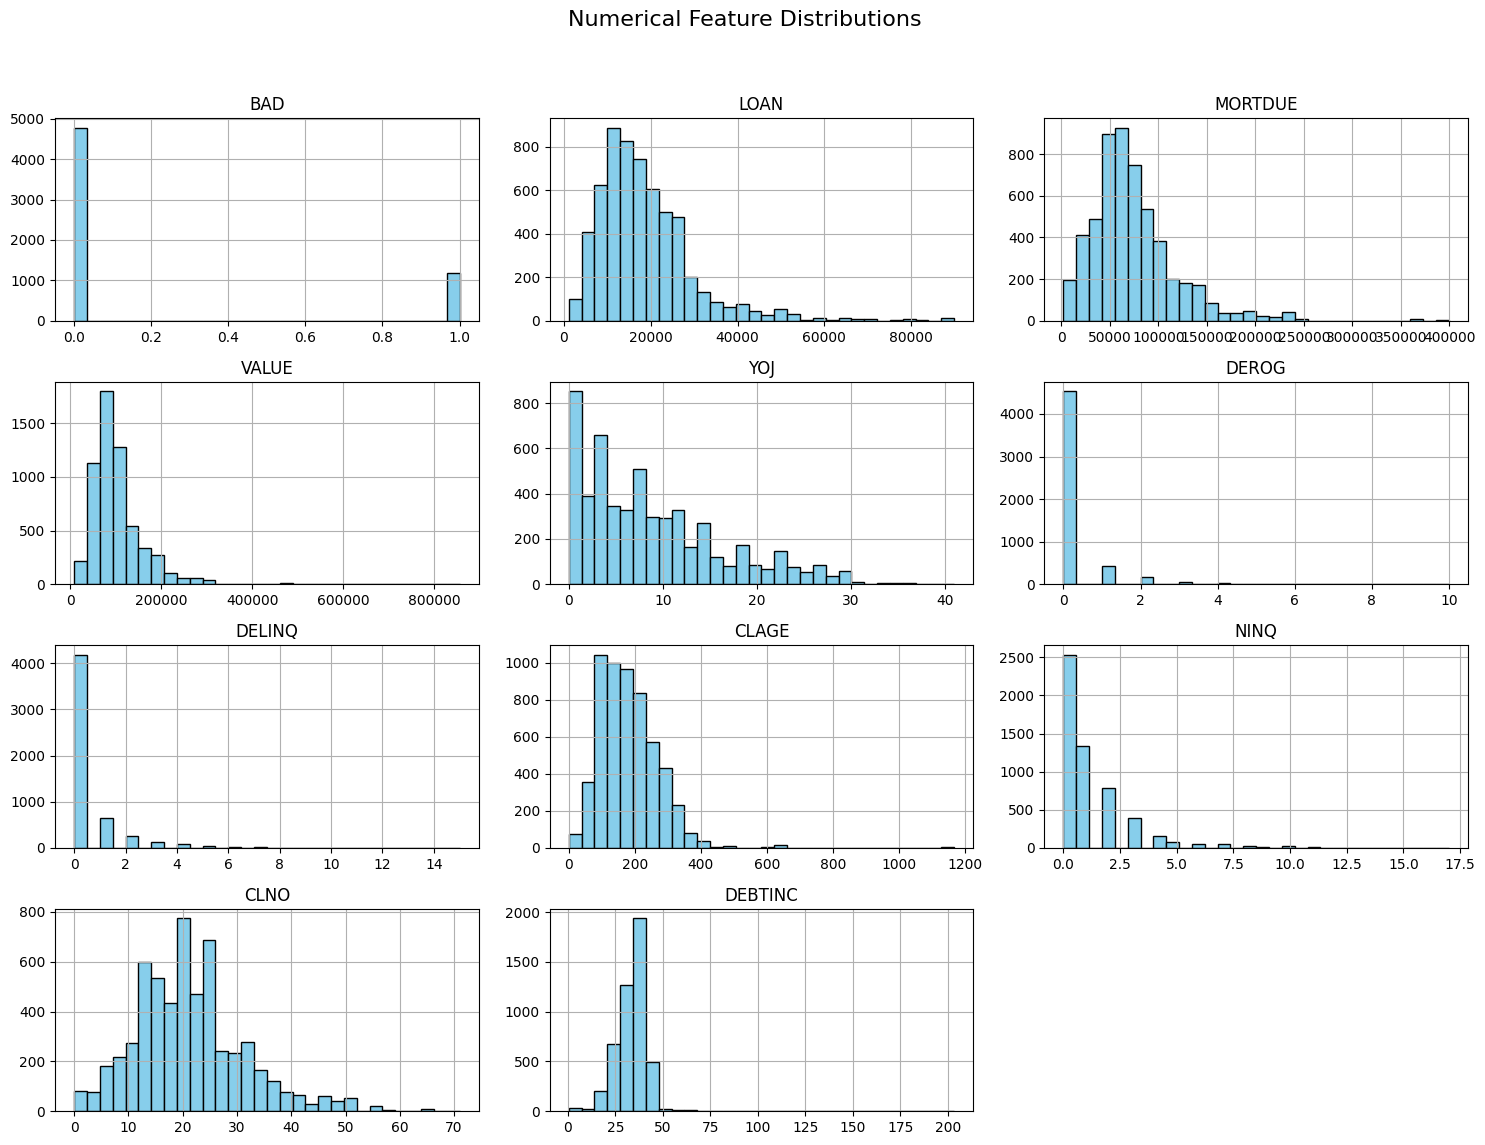

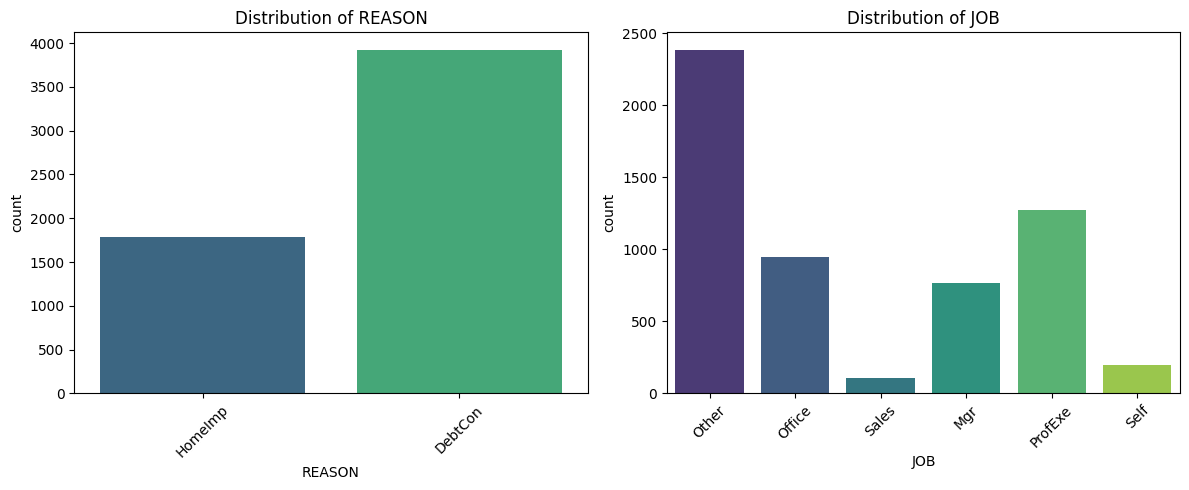

In [ ]:
def plot_loan_data(data):
  # 1. Identify numerical vs categorical columns
  num_cols = data.select_dtypes(include=['number']).columns
  cat_cols = data.select_dtypes(exclude=['number']).columns

  # 2. Plot Numerical Distributions (Histograms)
  data[num_cols].hist(figsize=(15, 12), bins=30, color='skyblue', edgecolor='black')
  plt.suptitle('Numerical Feature Distributions', fontsize=16)
  plt.tight_layout(rect=[0, 0.03, 1, 0.95])
  plt.show()

  # 3. Plot Categorical Distributions (Count Plots)
  plt.figure(figsize=(12, 5))
  for i, col in enumerate(cat_cols, 1):
      plt.subplot(1, len(cat_cols), i)
      sns.countplot(data=data, x=col, palette='viridis')
      plt.title(f'Distribution of {col}')
      plt.xticks(rotation=45)

  plt.tight_layout()
  plt.show()

#plot all loans
plot_loan_data(data)

LOAN Range: $1100 to $89900


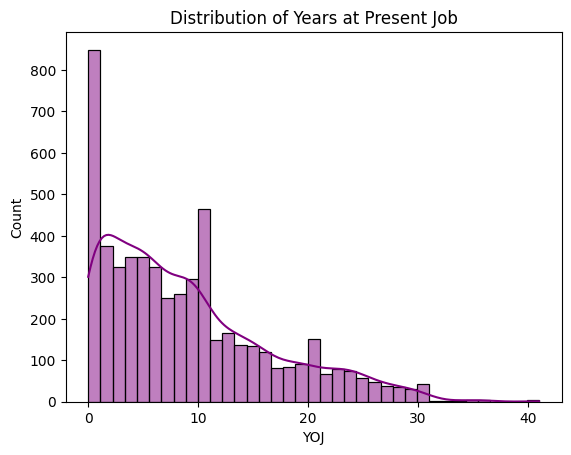

Unique categories in REASON: 2 (['HomeImp' nan 'DebtCon'])
The most common job category is: Other
Unique categories in JOB: 6 (['Other' nan 'Office' 'Sales' 'Mgr' 'ProfExe' 'Self'])


In [ ]:
# Range of LOAN amount
loan_min = data['LOAN'].min()
loan_max = data['LOAN'].max()
print(f"LOAN Range: ${loan_min} to ${loan_max}")

# Distribution of YOJ (Years at present job)
sns.histplot(data['YOJ'], kde=True, color='purple')
plt.title('Distribution of Years at Present Job')
plt.show()

# Unique categories in REASON
unique_reasons = data['REASON'].nunique()
print(f"Unique categories in REASON: {unique_reasons} ({data['REASON'].unique()})")

# Most common JOB
most_common_job = data['JOB'].mode()[0]
print(f"The most common job category is: {most_common_job}")

# Unqiue JOB categories
unique_jobs = data['JOB'].nunique()
print(f"Unique categories in JOB: {unique_jobs} ({data['JOB'].unique()})")


In [ ]:
#How many loans have a YOJ of 1 year or less
len(data[data['YOJ']<=1])

849

**Leading Questions Set I**:

- What is the range of values for the loan amount variable "LOAN"?
  - Loans range in size from \$1.1K to \$89.9K, with a mean loan size of ~\$18.6K
- How does the distribution of years at present job "YOJ" vary across the dataset?
  - Only 5445 loans reported a YOJ.  YOJ ranges from 0 to 41, with a mean of ~8.9 years.  Loans with a YOJ of \<=1 year are the largest single group (849 loans).  The distribution seems reasonable as the number of loans decreases as YOJ increases (people do not normally get to to stay at their present job for 41 years)
- How many unique categories are there in the REASON variable?
  - Only 5708 loans reported a reason (leaving the rest as nan).  There 2 categories: 'HomeImp' (Home improvement) and 'DebtCon' (Debt Consolidation).

- What is the most common category in the JOB variable?
  - Only 5681 loans reported a job (leaving the rest as nan).  "Other" was the most common job, with "ProfExec" being second most common.

### **Bivariate Analysis**

In [ ]:
result = pd.crosstab(data['REASON'], data['BAD'])
print(result)

BAD         0    1
REASON            
DebtCon  3183  745
HomeImp  1384  396


In [ ]:
# REASON vs Proportion of Default
# This calculates the percentage of defaults for each reason category
reason_impact = data.groupby('REASON')['BAD'].mean()
print("Proportion of defaults by Reason:\n", reason_impact)

# Correlation between Property VALUE and BAD
correlation_value = data['VALUE'].corr(data['BAD'])
print(f"Correlation between Property Value and Default: {correlation_value:.4f}")


Proportion of defaults by Reason:
 REASON
DebtCon    0.189664
HomeImp    0.222472
Name: BAD, dtype: float64
Correlation between Property Value and Default: -0.0300


**Leading Questions Set II**:

- Is there a relationship between the REASON variable and the proportion of applicants who defaulted on their loan?
  - Surprisingly, Home Improvement loans have a higher default rate (22.2%) compared to Debt Consolidation (18.9%). While banks often view debt consolidation as "riskier" because the borrower is already in debt, this dataset suggests that those borrowing to improve their homes are actually defaulting more frequently.



- Is there a correlation between the value of the property and the loan default rate?
  - There is a near-zero negative correlation (-0.03) between property value and default. The raw value of the home itself is a very weak predictor of whether someone will default. A person with a \$1M home isn't necessarily more reliable than someone with a \$100k home in this specific pool of borrowers.



In [ ]:
# Default vs LOAN Amount
repaid_loans = data[data['BAD'] == 0]['LOAN']
default_loans = data[data['BAD'] == 1]['LOAN']
t_stat, p_val = ttest_ind(repaid_loans, default_loans, nan_policy='omit')
print(f"LOAN Amount - T-stat: {t_stat}, P-value: {p_val}")

# Default vs MORTDUE Amount
repaid_mort = data[data['BAD'] == 0]['MORTDUE']
default_mort = data[data['BAD'] == 1]['MORTDUE']
t_stat_m, p_val_m = ttest_ind(repaid_mort, default_mort, nan_policy='omit')
print(f"MORTDUE Amount - T-stat: {t_stat_m}, P-value: {p_val_m}")


LOAN Amount - T-stat: 5.81315745785895, P-value: 6.448273297751198e-09
MORTDUE Amount - T-stat: 3.560612876121472, P-value: 0.00037315277915502335


**Leading Questions Set III**:
- Do applicants who default have a significantly different loan amount compared to those who repay their loan?
  - LOAN amount is reported for every loan.  LOAN has an extremely small p-value (~0.000000006) and below 0.05 . This is highly significant. There is a clear, non-random difference in the loan amounts requested by those who default versus those who repay.

- Do applicants who default have a significantly different mortgage amount compared to those who repay their loan?
  - Only 5442 loand have a MORTDUE value.  For reported MORTDUE values, there is an extremely small p-value (~0.00037) and below 0.05 . This is also significant. The amount currently owed on an existing mortgage is a strong indicator of future default status.


### **Multivariate Analysis**

**We will look at 3 visualizations**

1. Correlation Heatmap
2. Debt-to-Income vs. Credit Age
3. Pair Plots

**What we could be looking for:**

- **Redundancy**: If MORTDUE and VALUE are 95% correlated, you might only need one, or you can create a new feature like Equity (VALUE - MORTDUE).
- **Risk Profiles**: You might find that DEBTINC is a lethal predictor only when combined with high DEROG reports.
- **Interaction Effects**: It may turn out that high LOAN amounts are safe for Managers but highly risky for Self-Employed applicants.

### **Correlation Heatmap (Feature Interdependence)**
This identifies if any variables are redundant (multicollinearity). For example, MORTDUE and VALUE are likely highly correlated.

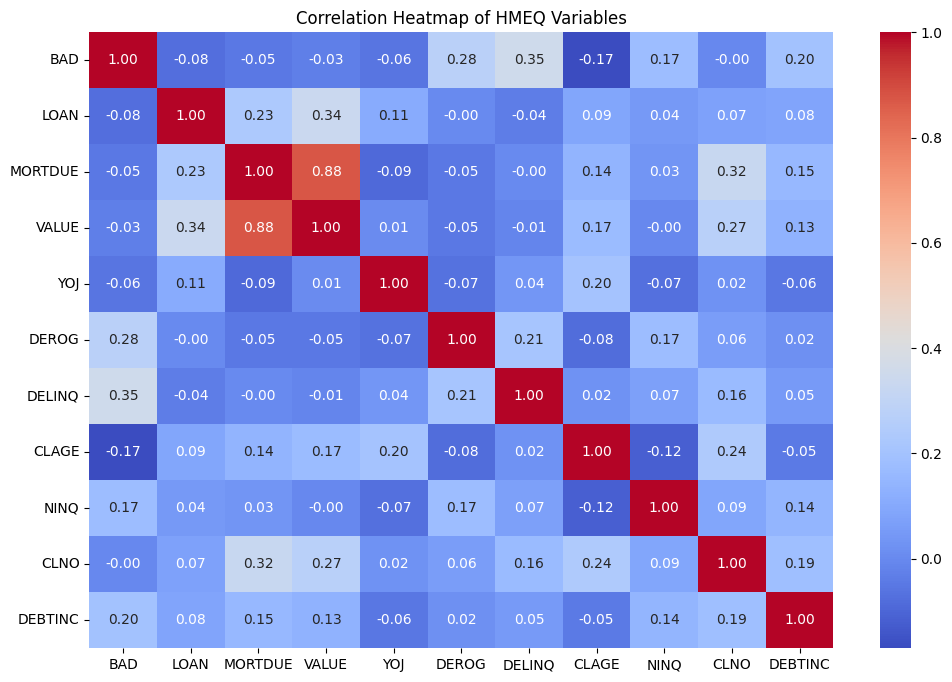

In [ ]:
plt.figure(figsize=(12, 8))

num_cols = data.select_dtypes(include=['number']).columns
# Focus on numerical variables
corr_matrix = data[num_cols].corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Heatmap of HMEQ Variables")
plt.show()

As expected **MORTDUE (mortgage due)** and the **VALUE** of the property are highly correlated (.88).  

**VALUE** of the property and the **LOAN (loan amount)** have some positive correlation (.34).

**BAD** loans and **DEROG (number of derogatory reports)** (.28) and **DELINQ (number of delinquant credit lines)** (.35) have some positive correlation.

**CLNO (number of credit lines)** also has some positive corrlation to **MORTDUE**  (.32)

There doesn't seem to be any other significant correlations, positive or negative.

### **Debt-to-Income vs. Credit Age**
This helps see "Risk Clusters." For example, do people with high DEBTINC default regardless of how long they’ve had credit (CLAGE)?

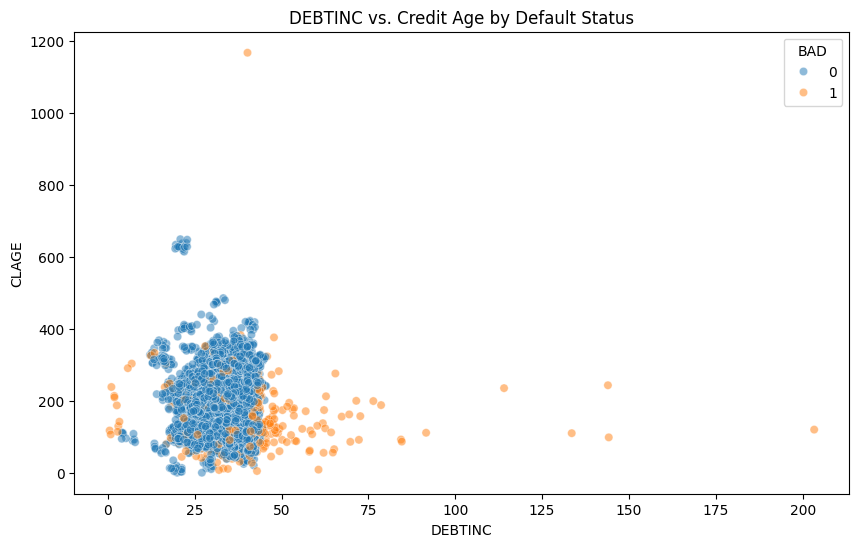

In [ ]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=data, x='DEBTINC', y='CLAGE', hue='BAD', alpha=0.5)
plt.title("DEBTINC vs. Credit Age by Default Status")
plt.show()

Clearly if your approve a loan for an applicant with a debt to income ratio higher than ~45%, you have a much higher likelihood it will default.

**Pair Plots (Segmented by Job or Reason)**

Since "Home Improvement" loans have higher defaults, let's  see how other features (like LOAN amount and DEROG reports) behave specifically for those segments.


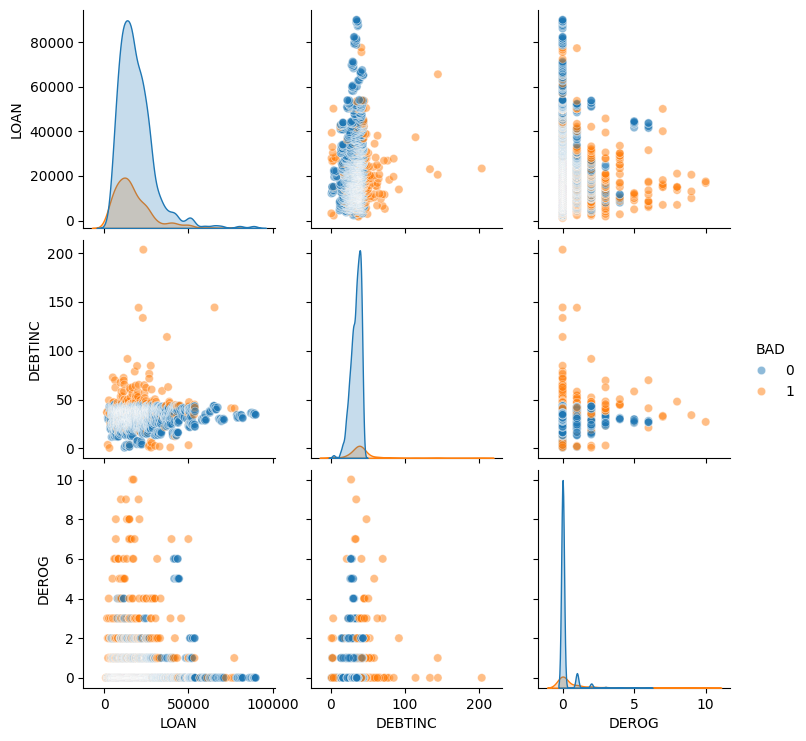

In [ ]:
# Select a subset of high-impact features to avoid a cluttered plot
cols = ['LOAN', 'DEBTINC', 'DEROG', 'BAD']
sns.pairplot(data[cols], hue='BAD', diag_kind='kde', plot_kws={'alpha':0.5})
plt.show()

### **Comparing good loans and bad loans**

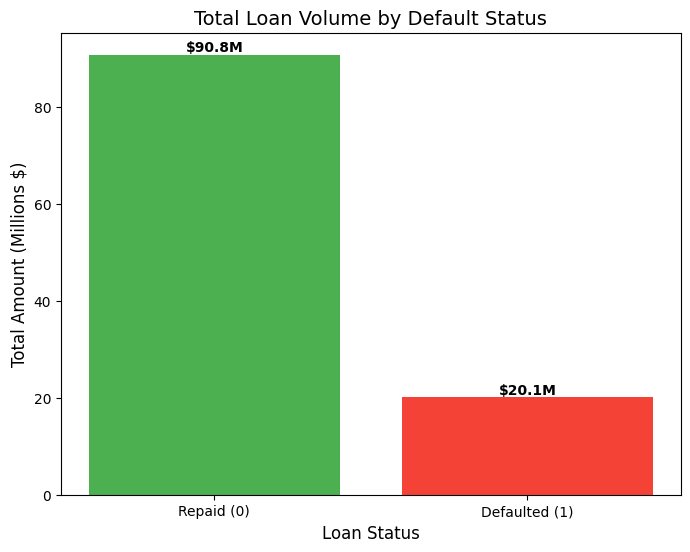

In [ ]:
# Grouping and dividing by 1 million
loan_summary_m = data.groupby('BAD')['LOAN'].sum() / 1e6

# Plotting
plt.figure(figsize=(8, 6))
bars = plt.bar(['Repaid (0)', 'Defaulted (1)'], loan_summary_m, color=['#4CAF50', '#F44336'])

# Formatting
plt.title('Total Loan Volume by Default Status', fontsize=14)
plt.xlabel('Loan Status', fontsize=12)
plt.ylabel('Total Amount (Millions $)', fontsize=12)

# Adding text labels on top of bars for clarity
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval, f'${yval:.1f}M',
             ha='center', va='bottom', fontweight='bold')

plt.show()

There are ~\$91M in good loans and ~\$20M lost in defaults

In [ ]:
#defaulted loans
bad_loans = data[data['BAD']==1]
bad_loans.describe().T

,count,mean,std,min,25%,50%,75%,max
BAD,1189.0,1.000000,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000
LOAN,1189.0,16922.119428,11418.455152,1100.000000,9200.000000,14900.000000,21700.000000,77400.000000
MORTDUE,1083.0,69460.452973,47588.194467,2063.000000,39946.500000,60279.000000,85864.500000,399550.000000
VALUE,1084.0,98172.846227,74339.822506,8800.000000,59368.250000,82000.000000,116000.000000,855909.000000
YOJ,1124.0,8.027802,7.100735,0.000000,2.000000,6.000000,12.000000,41.000000
DEROG,1102.0,0.707804,1.468381,0.000000,0.000000,0.000000,1.000000,10.000000
DELINQ,1117.0,1.229185,1.902961,0.000000,0.000000,0.000000,2.000000,15.000000
CLAGE,1111.0,150.190183,84.952286,0.000000,96.033333,132.866667,193.283333,1168.233561
NINQ,1114.0,1.782765,2.246976,0.000000,0.000000,1.000000,3.000000,17.000000
CLNO,1136.0,21.211268,11.812981,0.000000,13.000000,20.000000,28.000000,71.000000


In [ ]:
#good loans
good_loans = data[data['BAD']==0]
good_loans.describe().T

,count,mean,std,min,25%,50%,75%,max
BAD,4771.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
LOAN,4771.0,19028.107315,11115.758554,1700.000000,11700.000000,16900.000000,23500.000000,89900.000000
MORTDUE,4359.0,74829.249055,43584.993587,2619.000000,47484.000000,66839.000000,93068.000000,371003.000000
VALUE,4764.0,102595.921018,52748.392952,8000.000000,67297.750000,90659.000000,120615.500000,471827.000000
YOJ,4321.0,9.154941,7.676033,0.000000,3.000000,7.000000,13.000000,36.000000
DEROG,4150.0,0.134217,0.514490,0.000000,0.000000,0.000000,0.000000,6.000000
DELINQ,4263.0,0.245133,0.674124,0.000000,0.000000,0.000000,0.000000,5.000000
CLAGE,4541.0,187.002355,84.465217,0.486711,120.219885,180.415787,240.157802,649.747104
NINQ,4336.0,1.032749,1.531322,0.000000,0.000000,1.000000,2.000000,11.000000
CLNO,4602.0,21.317036,9.682601,0.000000,15.000000,20.000000,26.000000,56.000000


**Observations on defaulted loans**
- There 1189 Loans in default that make up ~20% of 5960 loans.
- Loans that defaulted ranged from \$1.1K to \$77.4K
- The average debt to income ratio was ~39.3%, about 6% higher than repaid loans.
- These loans had higher mean derogatory reports (DEROG) than repaid loans (.71 vs .13)  
- These loans had higher mean delinquant lines of credit than repaid loans (1.23 vs .25)



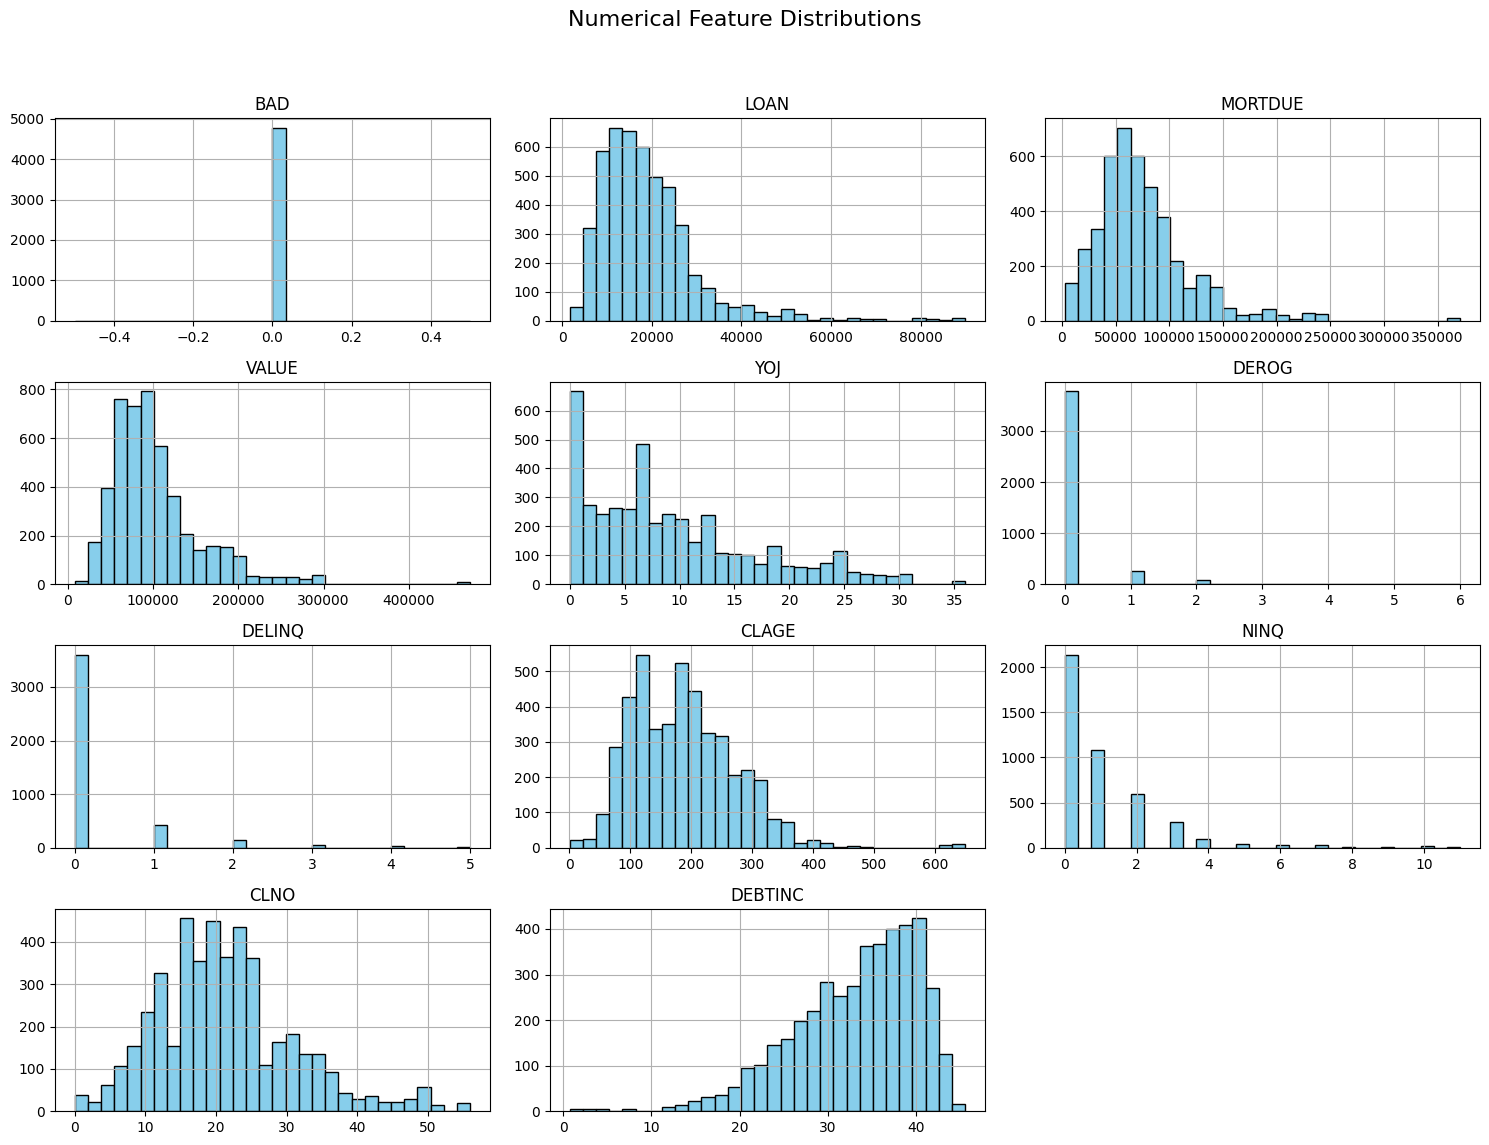

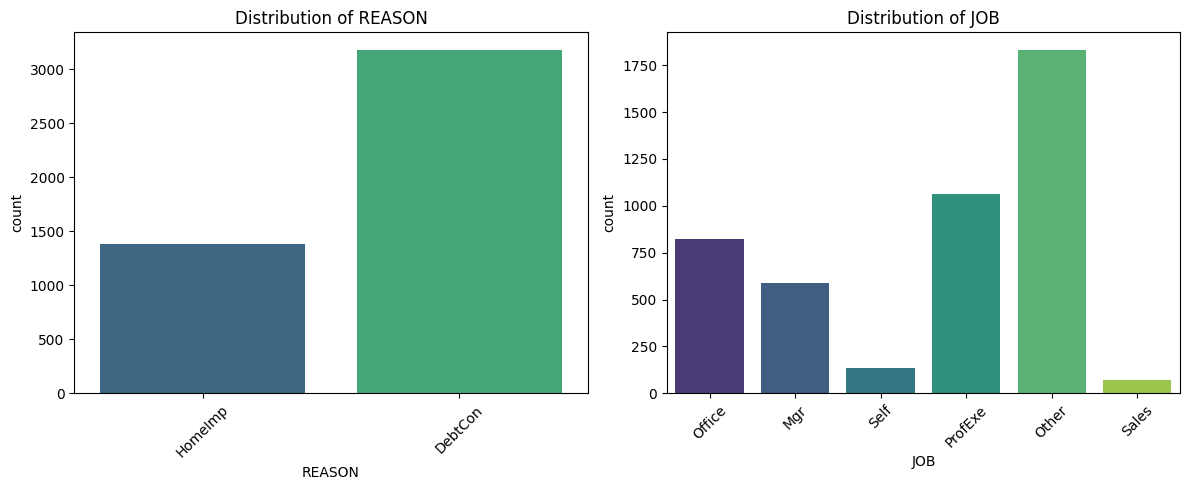

In [ ]:
#plot repaid loans
plot_loan_data(good_loans)

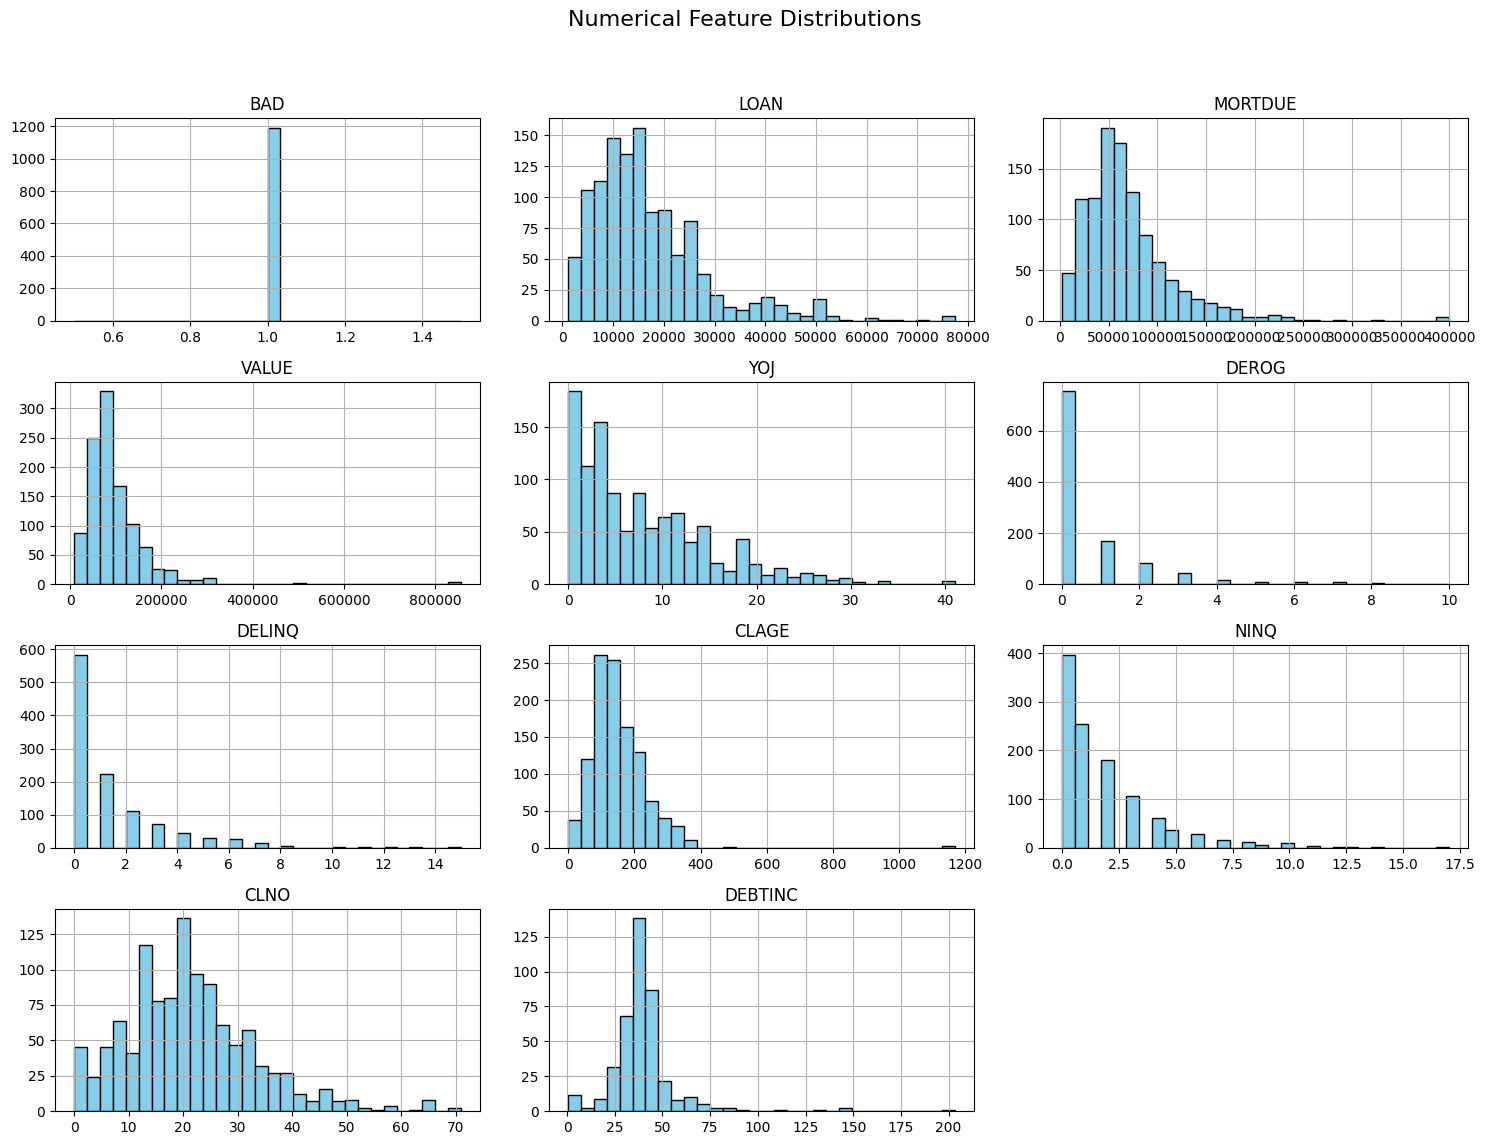

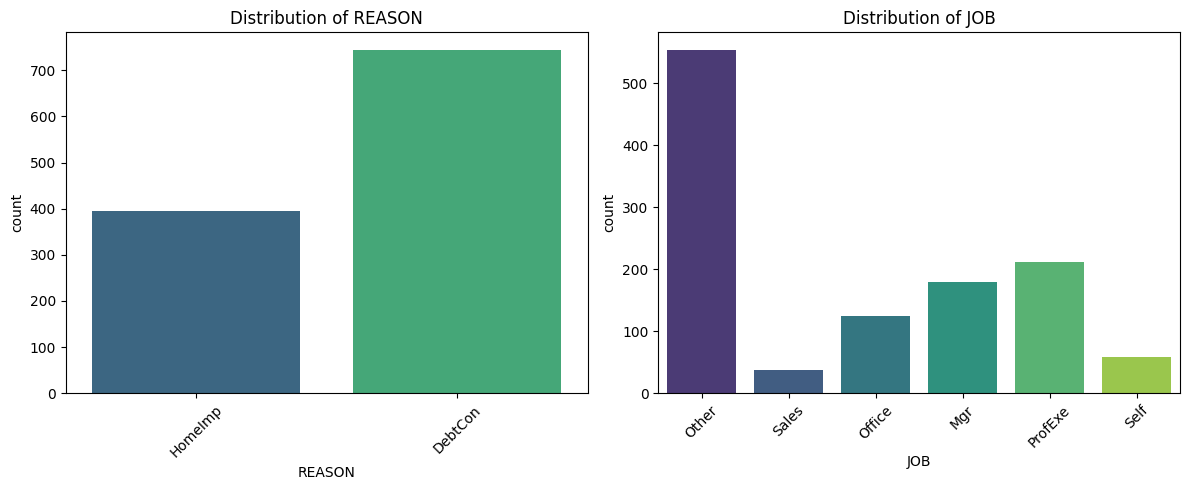

In [ ]:
#plot defaulted loans
plot_loan_data(bad_loans)

## Treating Outliers

**Outliers**

Financial variables like VALUE, LOAN, and DEBTINC often have extreme "long tails" (e.g., a few people requesting massive loans) that can distort the model's accuracy.
The most robust way to handle this without deleting data is the Interquartile Range (IQR) method to "cap" or "floor" the values.

**Handling Outliers**

- **Preventing Skew**: A single \$1M loan in a dataset where the average is \$20K can pull the model's "logic" toward that one extreme case.
- **Model Stability**: Algorithms like Linear Regression or Neural Networks are sensitive to outliers. Capping them makes your DEBTINC predictions much more reliable.
- **Exception for 'BAD' indicators**: Do not cap columns like DEROG or DELINQ. In those cases, the "outlier" (e.g., 10 delinquent credit lines) is exactly the signal the bank needs to see to deny a loan.

Note: I chose to handle outliers but depedning on the performance of my model I may choose keep them.


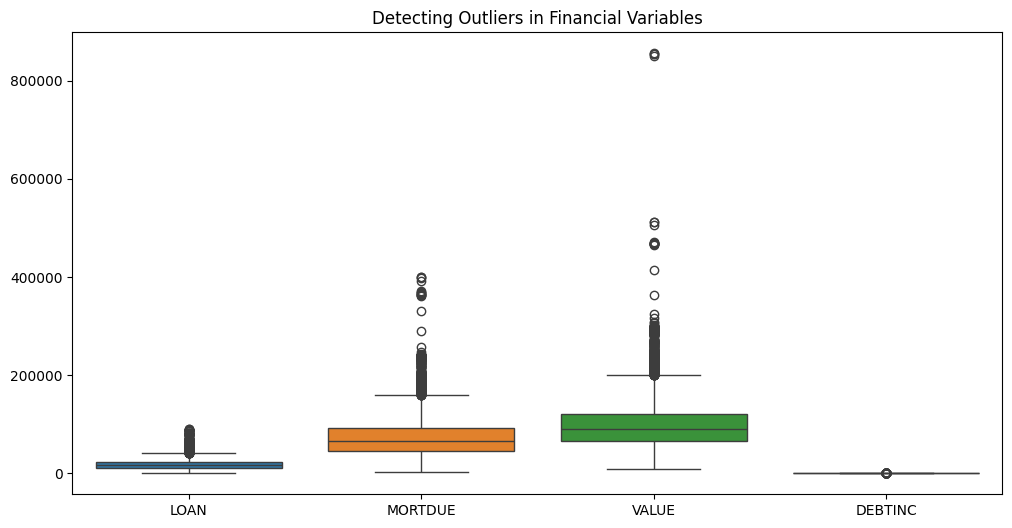

In [ ]:
#Copy the original dataset for outliers/correction
df = data.copy()

# Check key financial columns for outliers
cols_to_check = ['LOAN', 'MORTDUE', 'VALUE', 'DEBTINC']
plt.figure(figsize=(12, 6))
sns.boxplot(data=df[cols_to_check])
plt.title("Detecting Outliers in Financial Variables")
plt.show()


Instead of deleting rows (which would lose 20% of your data), we cap the outliers at the 1.5 * IQR boundary. This keeps the data point but brings its value within a reasonable range.

In [ ]:
def handle_outliers(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    # Cap the values
    df[column] = df[column].clip(lower=lower_bound, upper=upper_bound)
    return df

# Apply to continuous variables
continuous_vars = ['LOAN', 'MORTDUE', 'VALUE', 'YOJ', 'CLAGE', 'DEBTINC']
for col in continuous_vars:
    df = handle_outliers(df, col)

print("Outliers capped based on IQR boundaries.")

Outliers capped based on IQR boundaries.


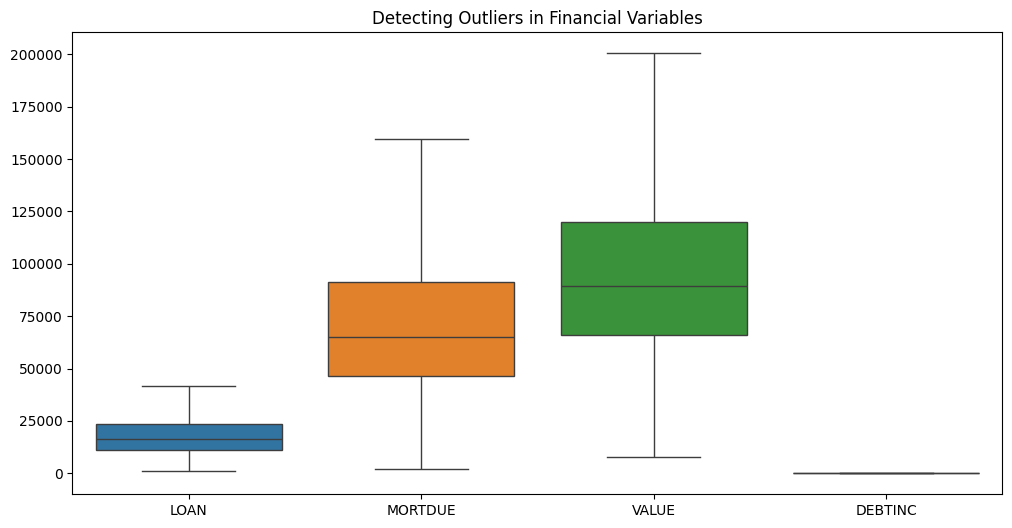

In [ ]:
# Check key financial columns for outliers
cols_to_check = ['LOAN', 'MORTDUE', 'VALUE', 'DEBTINC']
plt.figure(figsize=(12, 6))
sns.boxplot(data=df[cols_to_check])
plt.title("Detecting Outliers in Financial Variables")
plt.show()

## Treating Missing Values

**Missing Values**

The HMEQ dataset has significant missing values, particularly in DEBTINC (\~21%) and DEROG/DELINQ (\~10-12%). Handling these is critical because machine learning models cannot process NaN values.


**Corrections**

We will apply the following corrections.  Again, we could also consider throwing out the rows with nans but lets first explore making reasonable assumptions in the values.

- For REASON and JOB, we assume missing values follow the
general trend (most frequent value)
- For DEROG, DELINQ, and NINQ, a missing value often implies "zero" occurrences because if there were a delinquency, it would have been recorded.
- For skewed distributions (like DEBTINC, VALUE, MORTDUE), the median is safer than the mean.

In [ ]:
# 1. Categorical Imputation: Use the Mode (most frequent value)
# For REASON and JOB, we assume missing values follow the general trend.
for col in ['REASON', 'JOB']:
    df[col] = df[col].fillna(df[col].mode()[0])

# 2. Credit Behavior Imputation: Use 0
# For DEROG, DELINQ, and NINQ, a missing value often implies "zero" occurrences
# because if there were a delinquency, it would have been recorded.
for col in ['DEROG', 'DELINQ', 'NINQ']:
    df[col] = df[col].fillna(0)

# 3. Financial & Tenure Imputation: Use Median
# For skewed distributions (like DEBTINC, VALUE, MORTDUE), the median is safer than the mean.
num_cols = ['MORTDUE', 'VALUE', 'YOJ', 'CLAGE', 'CLNO', 'DEBTINC']
for col in num_cols:
    df[col] = df[col].fillna(df[col].median())

# Verify: Ensure Non-Null Count is now 5960 for all columns
print(df.isnull().sum())


BAD        0
LOAN       0
MORTDUE    0
VALUE      0
REASON     0
JOB        0
YOJ        0
DEROG      0
DELINQ     0
CLAGE      0
NINQ       0
CLNO       0
DEBTINC    0
dtype: int64


### Let's review the distributions and some visuals for the corrected dataset

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5960 entries, 0 to 5959
Data columns (total 13 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   BAD      5960 non-null   int64  
 1   LOAN     5960 non-null   int64  
 2   MORTDUE  5960 non-null   float64
 3   VALUE    5960 non-null   float64
 4   REASON   5960 non-null   object 
 5   JOB      5960 non-null   object 
 6   YOJ      5960 non-null   float64
 7   DEROG    5960 non-null   float64
 8   DELINQ   5960 non-null   float64
 9   CLAGE    5960 non-null   float64
 10  NINQ     5960 non-null   float64
 11  CLNO     5960 non-null   float64
 12  DEBTINC  5960 non-null   float64
dtypes: float64(9), int64(2), object(2)
memory usage: 605.4+ KB


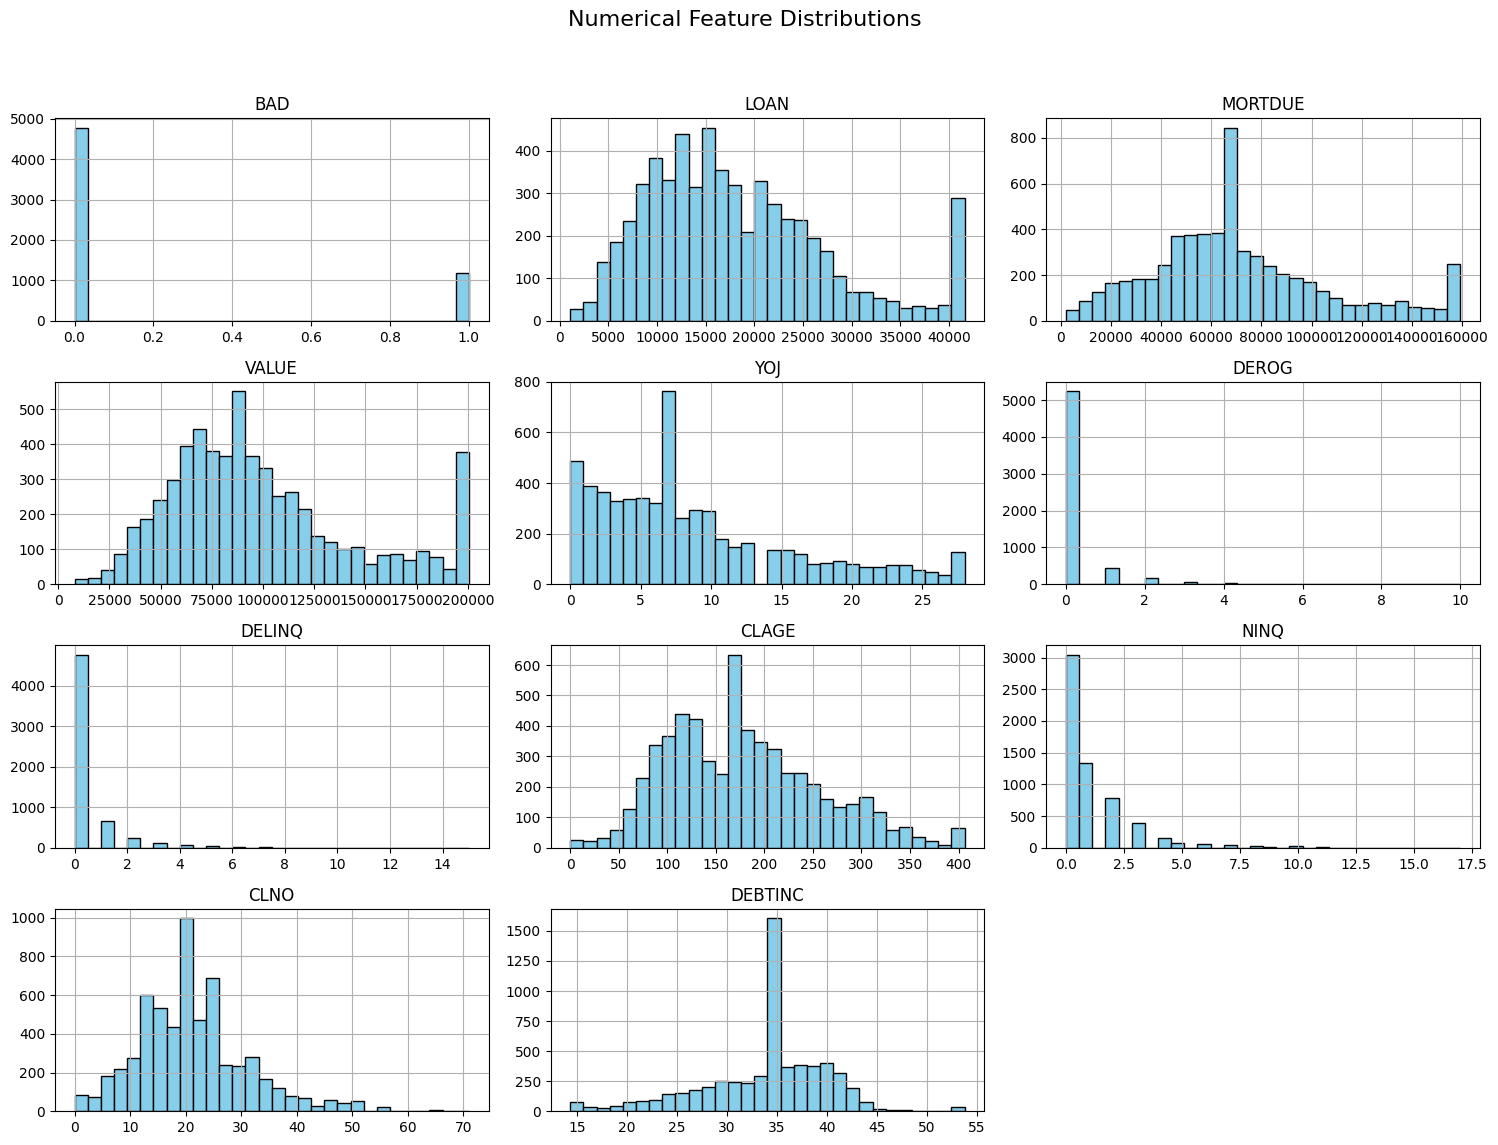

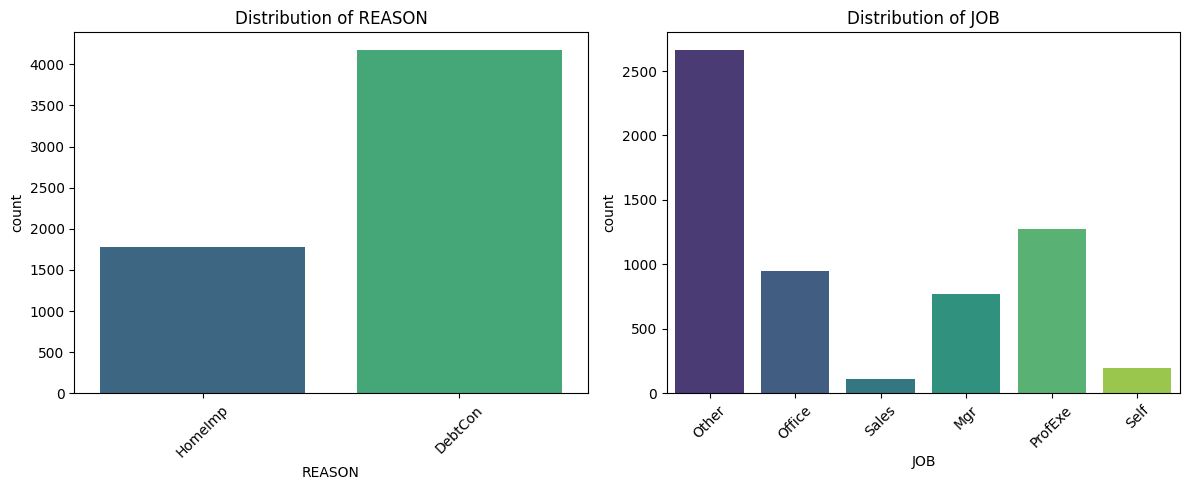

In [ ]:
#plot corrected dataset
plot_loan_data(df)

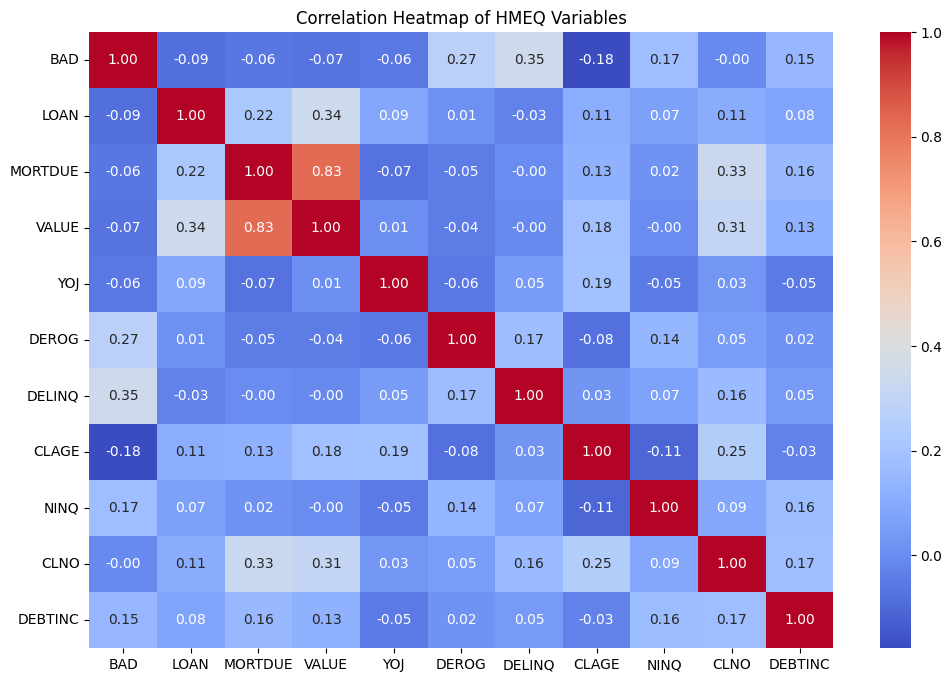

In [ ]:
plt.figure(figsize=(12, 8))

num_cols = df.select_dtypes(include=['number']).columns
# Focus on numerical variables
corr_matrix = df[num_cols].corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Heatmap of HMEQ Variables")
plt.show()

In [ ]:
# Default vs LOAN Amount
repaid_loans = df[df['BAD'] == 0]['LOAN']
default_loans = df[df['BAD'] == 1]['LOAN']
t_stat, p_val = ttest_ind(repaid_loans, default_loans, nan_policy='omit')
print(f"LOAN Amount - T-stat: {t_stat}, P-value: {p_val}")

# Default vs MORTDUE Amount
repaid_mort = df[df['BAD'] == 0]['MORTDUE']
default_mort = df[df['BAD'] == 1]['MORTDUE']
t_stat_m, p_val_m = ttest_ind(repaid_mort, default_mort, nan_policy='omit')
print(f"MORTDUE Amount - T-stat: {t_stat_m}, P-value: {p_val_m}")

LOAN Amount - T-stat: 6.586919490929015, P-value: 4.8751692809117464e-11
MORTDUE Amount - T-stat: 4.619142967412772, P-value: 3.934325033496768e-06


## **Important Insights from EDA**

What are the the most important observations and insights from the data based on the EDA performed?

* The HMEQ dataset has significant missing values, particularly in DEBTINC (\~21%) and DEROG/DELINQ (\~10-12%). Handling these is critical because machine learning models cannot process NaN values.
* Home Improvement loans have a higher default rate (22.2%) compared to Debt Consolidation (18.9%) suggests that those borrowing to improve their homes are actually defaulting more frequently.
* The raw value of the home itself is a very weak predictor of whether someone will default. A person with a \$1M home isn't necessarily more reliable than someone with a \$100k home in this specific pool of borrowers.
* There is a clear, non-random difference in the loan amounts requested by those who default versus those who repay.
* The amount currently owed on an existing mortgage is a strong indicator of future default status.


### **Model evaluation criterion**

**The model can make two types of wrong predictions:**

1. Predicting a loan will not default when the loan actually defaults
2. Predicting a loan will default when the loan will be repaid

**Which case is more important?**

* **Predicting a loan will not default when the loan actually defaults**, i.e., losing the unpaid principle amount of the loan. This would be considered a major miss for any loan default predictor and is hence the more important case of wrong predictions.

**How to reduce this loss i.e the need to reduce False Negatives?**
* **The company would want the Recall to be maximized**, the greater the Recall, the higher the chances of minimizing false negatives. Hence, the focus should be on increasing the Recall (minimizing the false negatives) or, in other words, identifying the true positives (i.e. Class 1) very well, so that the company can reliably identify loans that would default and automatically not approving them, avoid the loss of principal, and reduce/eliminate employee effort on evaluating or reviewing loans likely to default.

## **Model Building - Approach**
- Data preparation
- Partition the data into train and test set
- Build the model
- Fit on the train data
- Tune the model
- Test the model on test set

We are going to contrast and compare performance of:


* Logistic Regression Model
* Decision Tree Model
* Random Forest Model



### Logistic Regression



In [ ]:
#Data Preparation
# 1. Encoding Categorical Variables (JOB and REASON)
df_encoded = pd.get_dummies(df, columns=['JOB', 'REASON'], drop_first=True)

# 2. Splitting Features (X) and Target (y)
x = df_encoded.drop('BAD', axis=1)
y = df_encoded['BAD']

df_encoded.head()

,BAD,LOAN,MORTDUE,VALUE,YOJ,DEROG,DELINQ,CLAGE,NINQ,CLNO,DEBTINC,JOB_Office,JOB_Other,JOB_ProfExe,JOB_Sales,JOB_Self,REASON_HomeImp
0,1,1100,25860.0,39025.0,10.5,0.0,0.0,94.366667,1.0,9.0,34.818262,False,True,False,False,False,True
1,1,1300,70053.0,68400.0,7.0,0.0,2.0,121.833333,0.0,14.0,34.818262,False,True,False,False,False,True
2,1,1500,13500.0,16700.0,4.0,0.0,0.0,149.466667,1.0,10.0,34.818262,False,True,False,False,False,True
3,1,1500,65019.0,89235.5,7.0,0.0,0.0,173.466667,0.0,20.0,34.818262,False,True,False,False,False,False
4,0,1700,97800.0,112000.0,3.0,0.0,0.0,93.333333,0.0,14.0,34.818262,True,False,False,False,False,True


In [ ]:
def model_performance_classification(model, predictors, target):
    """
    Function to compute different metrics to check classification model performance

    model: classifier

    predictors: independent variables

    target: dependent variable
    """

    # Predicting using the independent variables
    pred = model.predict(predictors)

    recall = recall_score(target, pred,average = 'macro')                 # To compute recall

    precision = precision_score(target, pred, average = 'macro')              # To compute precision

    acc = accuracy_score(target, pred)                                 # To compute accuracy score


    # Creating a dataframe of metrics

    df_perf = pd.DataFrame(
        {
            "Precision":  precision,
            "Recall":  recall,
            "Accuracy": acc,
        },

        index = [0],
    )

    return df_perf

# Creating metric function

def metrics_score(actual, predicted):

    print(classification_report(actual, predicted))

    cm = confusion_matrix(actual, predicted)

    plt.figure(figsize = (8, 5))

    sns.heatmap(cm, annot = True, fmt = '.2f', xticklabels = ['Repaid', 'Defaulted'], yticklabels = ['Repaid', 'Defaulted'])
    plt.ylabel('Actual')

    plt.xlabel('Predicted')

    plt.show()

              precision    recall  f1-score   support

           0       0.89      0.78      0.83       954
           1       0.41      0.61      0.49       238

    accuracy                           0.75      1192
   macro avg       0.65      0.70      0.66      1192
weighted avg       0.79      0.75      0.76      1192



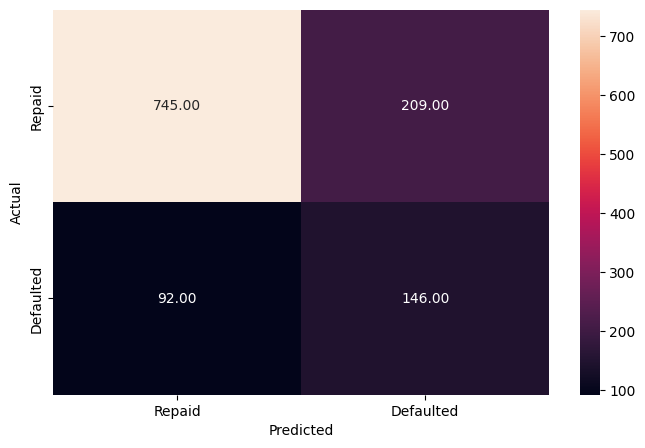

In [ ]:
# Partition the data
# 3. Train-Test Split (80/20)
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42, stratify=y)

# 4. Feature Scaling (Crucial for Logistic Regression)
scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)

# 5. Initialize and Train the Model
# We use 'class_weight="balanced"' because only 20% of the data are defaults
# By setting class_weight='balanced', we told the model to pay extra attention to the BAD=1 cases,
# which prevents it from just guessing 0 for everyone to get 80% accuracy.
log_model = LogisticRegression(class_weight='balanced', random_state=42)
log_model.fit(x_train_scaled, y_train)

# 6. Predictions
y_pred = log_model.predict(x_test_scaled)


metrics_score(y_test, y_pred)
#print("\nClassification Report:\n", classification_report(y_test, y_pred))

**Looking at the results**

- **Recall for Class 1 (Bad Loans) (61%)**: Since the bank is "fearful of defaulters," we want Recall for Class 1 (BAD loans) to be high so we catch as many potential bad loans as possible. 61% which is not great as we incorrectly predicted 92 bad loans as good ones.

- **Precision (Very poor at 41%)**:  We flagged 209 "good" customers as risky (False Positives). If the bank automatically rejects these people, they are losing out on significant interest income from 209 reliable borrowers.




In [ ]:
log_test = model_performance_classification(log_model,x_test,y_test)
log_test


,Precision,Recall,Accuracy
0,0.400168,0.5,0.800336


In [ ]:
# Create a dataframe of features and their coefficients
importance = pd.DataFrame({
    'Feature': x.columns,
    'Coefficient': log_model.coef_[0]
})

# Sort by absolute value to see the most influential features
importance['Abs_Coefficient'] = importance['Coefficient'].abs()
importance = importance.sort_values(by='Abs_Coefficient', ascending=False)

print(importance[['Feature', 'Coefficient']])

           Feature  Coefficient
5           DELINQ     0.912621
4            DEROG     0.514155
9          DEBTINC     0.481924
6            CLAGE    -0.480996
10      JOB_Office    -0.252894
7             NINQ     0.245287
0             LOAN    -0.219783
13       JOB_Sales     0.178796
1          MORTDUE    -0.131791
15  REASON_HomeImp     0.127293
14        JOB_Self     0.126412
8             CLNO    -0.125113
3              YOJ    -0.066706
11       JOB_Other     0.041967
12     JOB_ProfExe     0.026807
2            VALUE    -0.009220


**Insights**
- DELINQ (0.91): This is by far the strongest predictor. For every delinquent credit line an applicant has, the odds of them defaulting nearly double. This is a massive "red flag."

- DEROG (0.51): Major derogatory reports are the second-highest warning sign, confirming that past serious delinquency is a reliable predictor of future behavior.

- DEBTINC (0.48): As expected, as the debt-to-income ratio
climbs, so does the risk. The bank should be very cautious with any applicant approaching the upper limits of this ratio.

- CLAGE (-0.48): This is the strongest "good" signal. A long history of credit age significantly offsets risk. Even if someone has a slightly higher loan amount, a high CLAGE suggests they know how to manage credit long-term.

**Surprising Insights**
- LOAN (-0.21): Interestingly, in this model, a higher loan amount actually decreases the probability of default. This suggests that the "bad" loans in this dataset are often smaller, perhaps "emergency" requests, while larger loans are being taken out by more stable, vetted individuals.

- JOB_Office (-0.25): Applicants with office jobs are statistically the safest group in the JOB category.

- VALUE (-0.009): Property value is almost completely irrelevant to the model. A high-value home does not make an applicant more likely to repay if their DELINQ or DEBTINC numbers are bad.

**Potential Recommendation**
- The model is currently punishing applicants heavily for past mistakes (DELINQ, DEROG). To improve that 0.41 precision (and stop rejecting good customers), the bank should consider a policy where a high CLAGE (credit age) can "rescue" an application that has a slightly elevated DEBTINC.




### Decision Tree

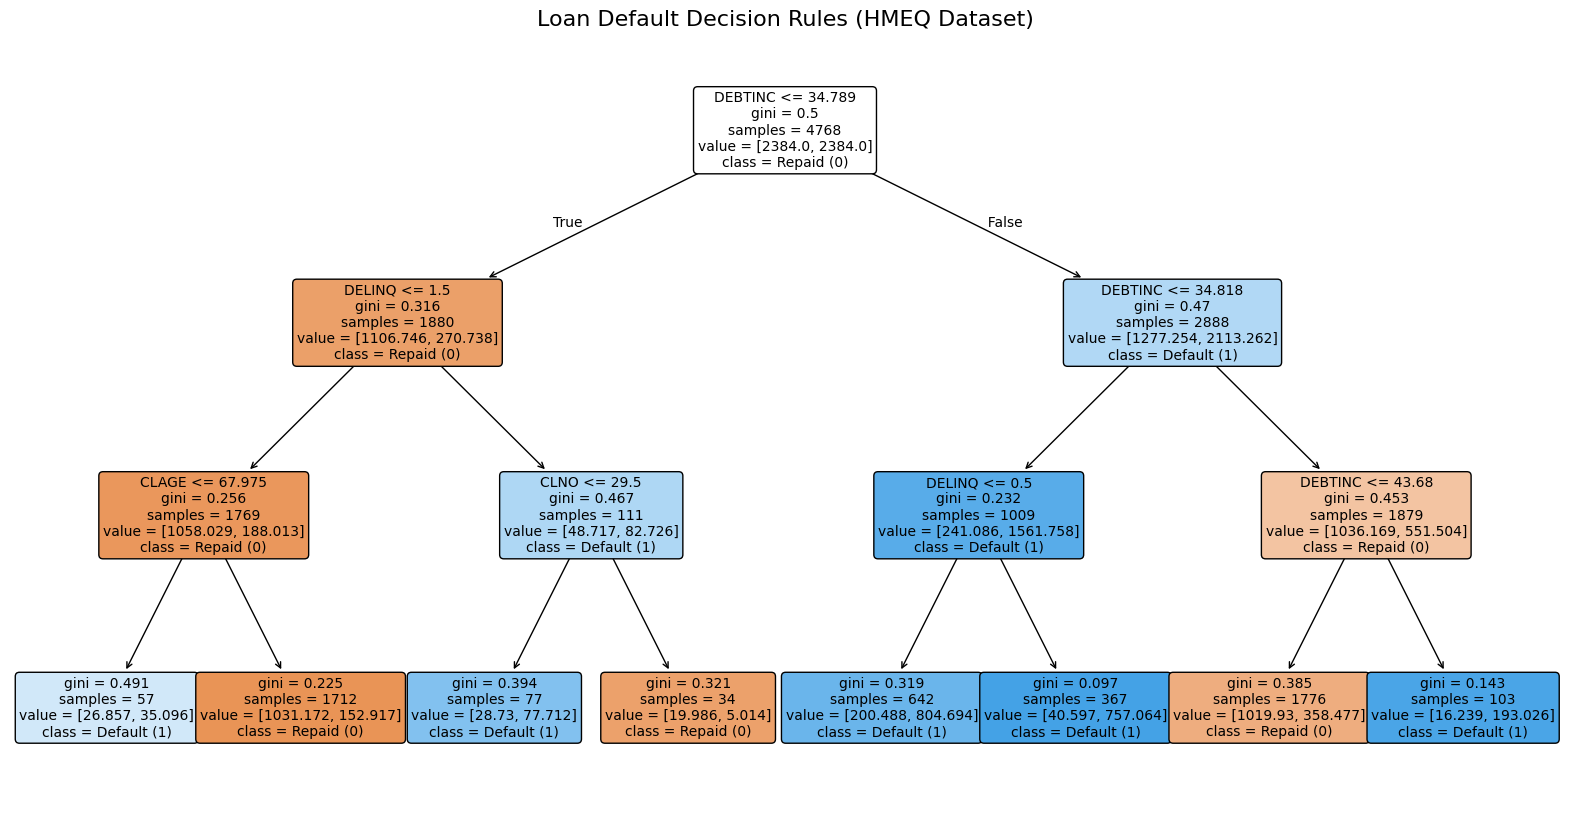

In [ ]:
# 1. Initialize the Decision Tree
# We use max_depth=3 so the visualization remains readable and provides high-level rules
dt_model = DecisionTreeClassifier(max_depth=3, class_weight='balanced', random_state=42)

# 2. Fit the model (using your encoded x and y from the Logistic Regression step)
dt_model.fit(x_train, y_train)

# 3. Plot the Tree
plt.figure(figsize=(20, 10))
plot_tree(dt_model,
          feature_names=x.columns,
          class_names=['Repaid (0)', 'Default (1)'],
          filled=True,
          rounded=True,
          fontsize=10)

plt.title("Loan Default Decision Rules (HMEQ Dataset)", fontsize=16)
plt.show()

This tree basically shows if `DEBTINC` is greater than ~34.7%, but under ~34.81% and have a `DELINQ` you have a higher likelihood of default.

              precision    recall  f1-score   support

           0       0.94      0.87      0.90      3817
           1       0.60      0.78      0.68       951

    accuracy                           0.85      4768
   macro avg       0.77      0.83      0.79      4768
weighted avg       0.87      0.85      0.86      4768



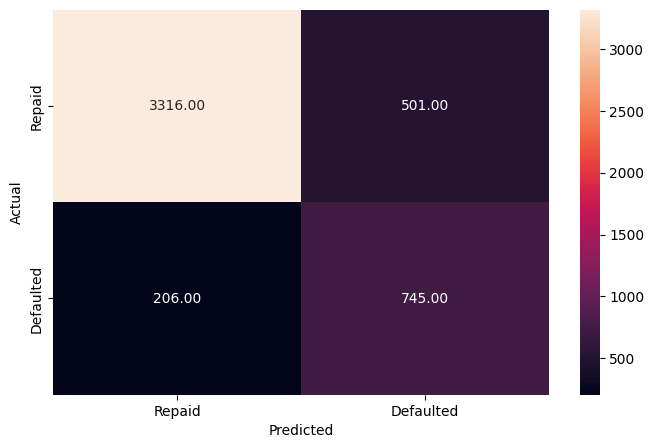

In [ ]:
# Checking performance on the training dataset
y_train_pred_dt = dt_model.predict(x_train)

metrics_score(y_train, y_train_pred_dt)

Recall is 78% and Precision is 60% for bad loans on the training data.

              precision    recall  f1-score   support

           0       0.94      0.86      0.90       954
           1       0.58      0.78      0.67       238

    accuracy                           0.84      1192
   macro avg       0.76      0.82      0.78      1192
weighted avg       0.87      0.84      0.85      1192



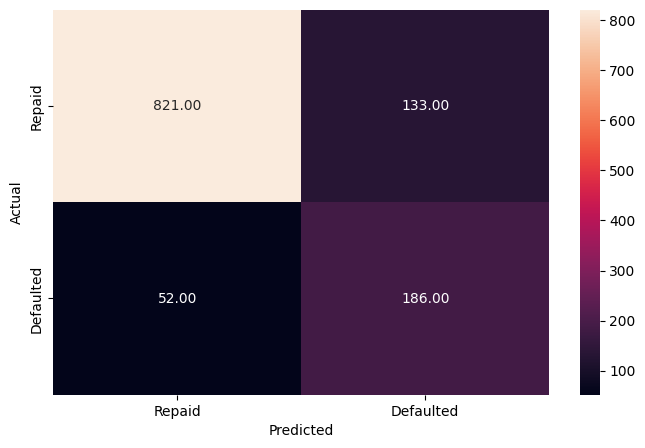

In [ ]:
y_test_pred_dt = dt_model.predict(x_test)

metrics_score(y_test, y_test_pred_dt)

Recall is 78% and Precision is 58% for bad loans on the test data.

The precision on the test data suggests that there's a 42% (1 - 0.58) chance that the model will predict a loan will default when it would actually would be repaid.


In [ ]:
dtree_test = model_performance_classification(dt_model,x_test,y_test)
dtree_test

,Precision,Recall,Accuracy
0,0.761754,0.82105,0.844799


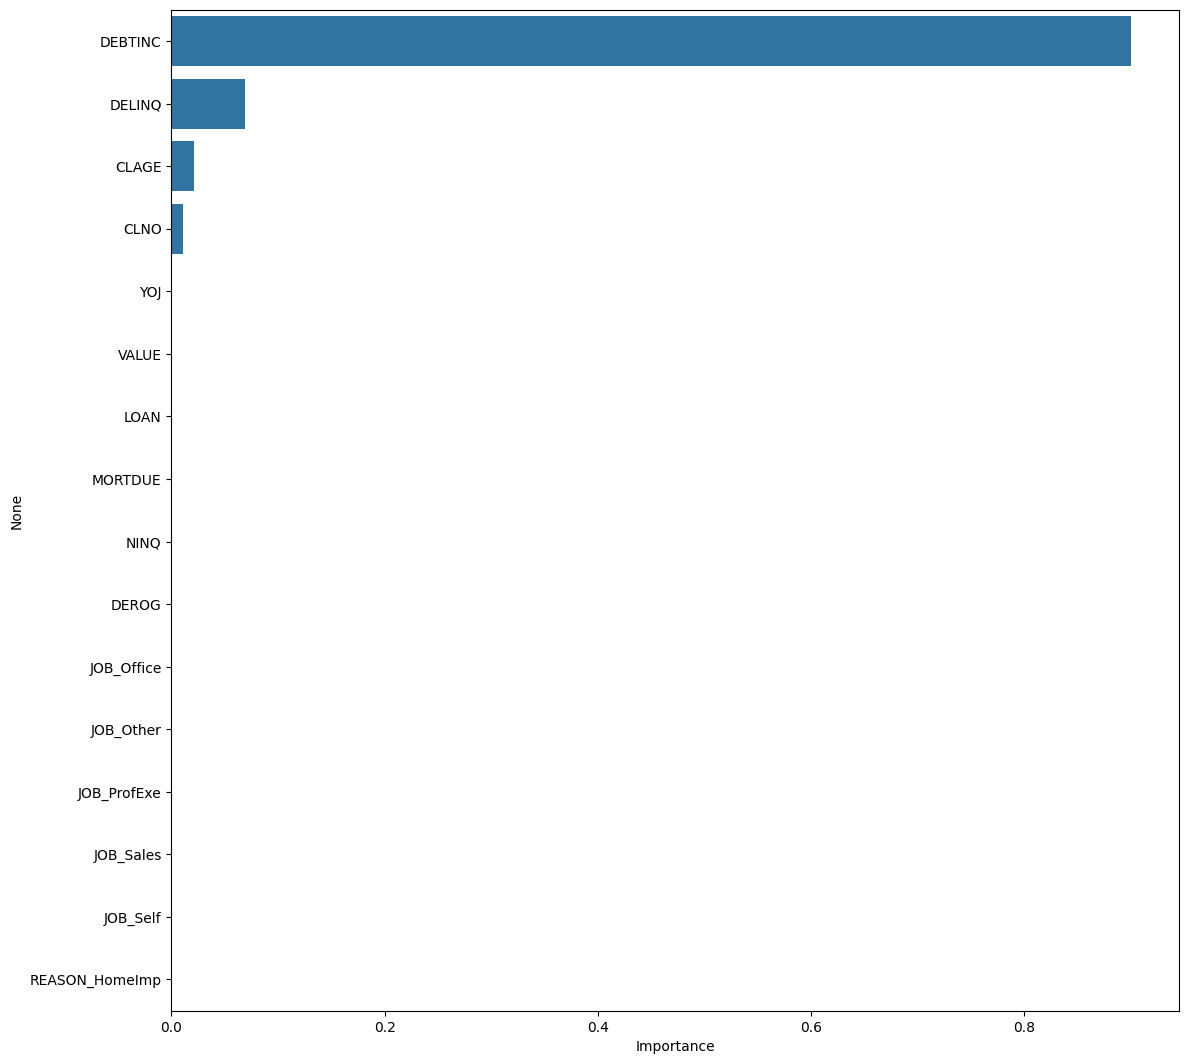

In [ ]:
# Plot the feature importance

importances = dt_model.feature_importances_

columns = x.columns

importance_df = pd.DataFrame(importances, index = columns, columns = ['Importance']).sort_values(by = 'Importance', ascending = False)

plt.figure(figsize = (13, 13))

sns.barplot(x=importance_df.Importance,y=importance_df.index);

**Observations:**

- According to the Decision Tree, **DEBTINC is the most important feature by far, followed by DELINQ, CLAGE, and CLNO**
- This might signify applications which are most likely to default have high debt to income ratios, more credit lines in deliquancy, and have shortest age of credit lines.


### **Decision Tree - Hyperparameter Tuning**

* Hyperparameter tuning is tricky in the sense that **there is no direct way to calculate how a change in the hyperparameter value will reduce the loss of your model**, so we usually resort to experimentation. We'll use Grid search to perform hyperparameter tuning.
* **Grid search is a tuning technique that attempts to compute the optimum values of hyperparameters.**
* **It is an exhaustive search** that is performed on the specific parameter values of a model.
* The parameters of the estimator/model used to apply these methods are **optimized by cross-validated grid-search** over a parameter grid.

**Criterion {“gini”, “entropy”}**

The function to measure the quality of a split. Supported criteria are “gini” for the Gini impurity and “entropy” for the information gain.

**max_depth**

The maximum depth of the tree. If None, then nodes are expanded until all leaves are pure or until all leaves contain less than min_samples_split samples.

**min_samples_leaf**

The minimum number of samples is required to be at a leaf node. A split point at any depth will only be considered if it leaves at least min_samples_leaf training samples in each of the left and right branches. This may have the effect of smoothing the model, especially in regression.

You can learn about more Hyperpapameters on this link and try to tune them.

https://scikit-learn.org/stable/modules/generated/sklearn.tree.DecisionTreeClassifier.html


In [ ]:
# Choose the type of classifier
dtree_estimator = DecisionTreeClassifier(class_weight = {0: 0.17, 1: 0.83}, random_state = 1)

# Grid of parameters to choose from
parameters = {'max_depth': np.arange(2, 7),
              'criterion': ['gini', 'entropy'],
              'min_samples_leaf': [5, 10, 20, 25]
             }

# Type of scoring used to compare parameter combinations
scorer = metrics.make_scorer(recall_score, pos_label = 1)

# Run the grid search
gridCV = GridSearchCV(dtree_estimator, parameters, scoring = scorer, cv = 10)

# Fitting the grid search on the train data
gridCV = gridCV.fit(x_train, y_train)

# Set the classifier to the best combination of parameters
dtree_estimator = gridCV.best_estimator_

# Fit the best estimator to the data
dtree_estimator.fit(x_train, y_train)

DecisionTreeClassifier(class_weight={0: 0.17, 1: 0.83}, criterion='entropy',
                       max_depth=np.int64(6), min_samples_leaf=20,
                       random_state=1)

              precision    recall  f1-score   support

           0       0.96      0.83      0.89      3817
           1       0.56      0.86      0.68       951

    accuracy                           0.84      4768
   macro avg       0.76      0.85      0.79      4768
weighted avg       0.88      0.84      0.85      4768



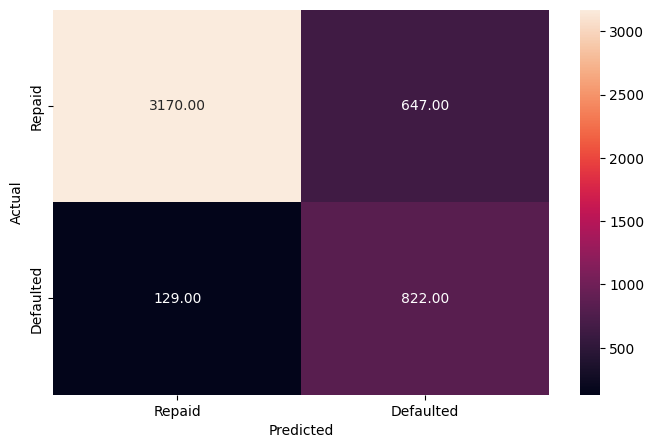

In [ ]:
# Checking performance on the training dataset
y_train_pred_dt = dtree_estimator.predict(x_train)

metrics_score(y_train, y_train_pred_dt)

**Observations**

- The recall for bad loans on the trained data using the tuned model improved from 78% to 86%, while sacrificing some precision (went from 60% to 56%)


              precision    recall  f1-score   support

           0       0.94      0.82      0.88       954
           1       0.53      0.81      0.64       238

    accuracy                           0.82      1192
   macro avg       0.74      0.82      0.76      1192
weighted avg       0.86      0.82      0.83      1192



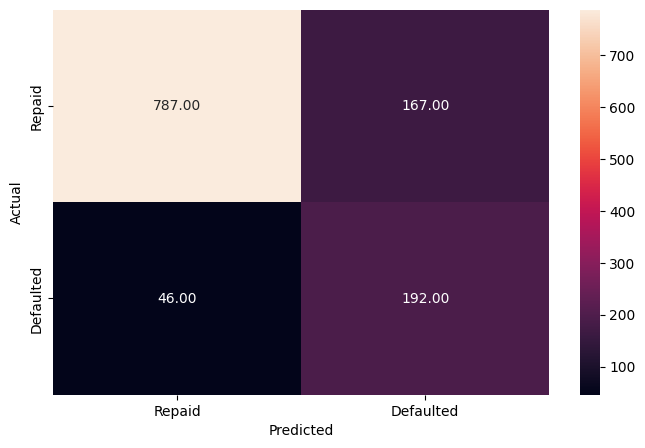

In [ ]:
# Checking performance on the test dataset
y_test_pred_dt = dtree_estimator.predict(x_test)

metrics_score(y_test, y_test_pred_dt)

**Observations**

- The recall for bad loans on the test data using the tuned model improved from 78% to 81%, while sacrificing some precision (went from 58% to 53%)


In [ ]:
dtree_tuned_test = model_performance_classification(dtree_estimator,x_test,y_test)
dtree_tuned_test

,Precision,Recall,Accuracy
0,0.739798,0.815835,0.821309


**Observations**
- The tuned model is not performing well in comparison to the model with default values of hyperparameters.
- The recall stayed roughly flat 82% to 81%
- The precision went from 76% to 73% giving a higher number of false positives (loans that were rejected we should have approved)



### **Building a Random Forest Classifier**

**Random Forest is a bagging algorithm where the base models are Decision Trees.** Samples are taken from the training data and on each sample a decision tree makes a prediction.

**The results from all the decision trees are combined together and the final prediction is made using voting or averaging.**

In [ ]:
# Fitting the Random Forest classifier on the training data
rf_estimator = RandomForestClassifier(class_weight = {0: 0.17, 1: 0.83}, random_state = 1)

rf_estimator.fit(x_train, y_train)

RandomForestClassifier(class_weight={0: 0.17, 1: 0.83}, random_state=1)

              precision    recall  f1-score   support

           0       1.00      1.00      1.00      3817
           1       1.00      1.00      1.00       951

    accuracy                           1.00      4768
   macro avg       1.00      1.00      1.00      4768
weighted avg       1.00      1.00      1.00      4768



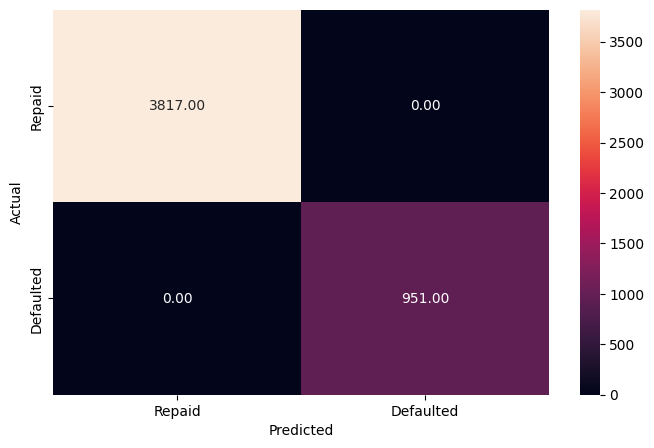

In [ ]:
# Checking performance on the training data
y_pred_train_rf = rf_estimator.predict(x_train)

metrics_score(y_train, y_pred_train_rf)

**Observation:**

- The Random Forest is giving a 100% score for all metrics on the training dataset.

              precision    recall  f1-score   support

           0       0.90      0.98      0.94       954
           1       0.86      0.58      0.69       238

    accuracy                           0.90      1192
   macro avg       0.88      0.78      0.81      1192
weighted avg       0.89      0.90      0.89      1192



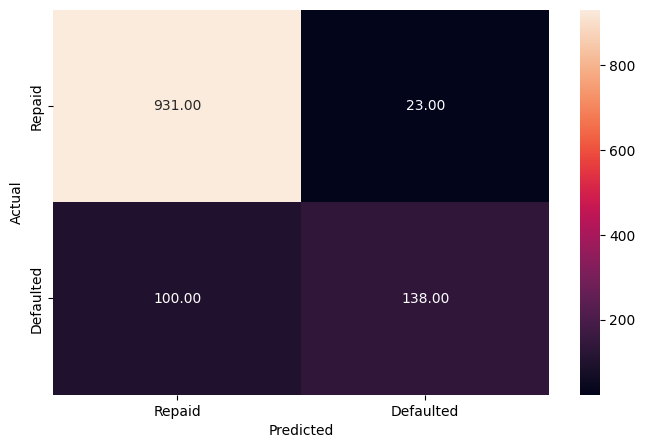

In [ ]:
# Checking performance on the testing data
y_pred_test_rf = rf_estimator.predict(x_test)

metrics_score(y_test, y_pred_test_rf)

**Observations:**

- The Random Forest classifier **seems to be overfitting the training data**. The recall on the training data is 100%, while the recall on the test data is only ~ 58% for class 1.
- Precision is higher for the traing data 100% vs the test data 86% as well.

In [ ]:
rf_estimator_test = model_performance_classification(rf_estimator,x_test,y_test)
rf_estimator_test

,Precision,Recall,Accuracy
0,0.880075,0.777861,0.896812


**Let's check the feature importance of the Random Forest**

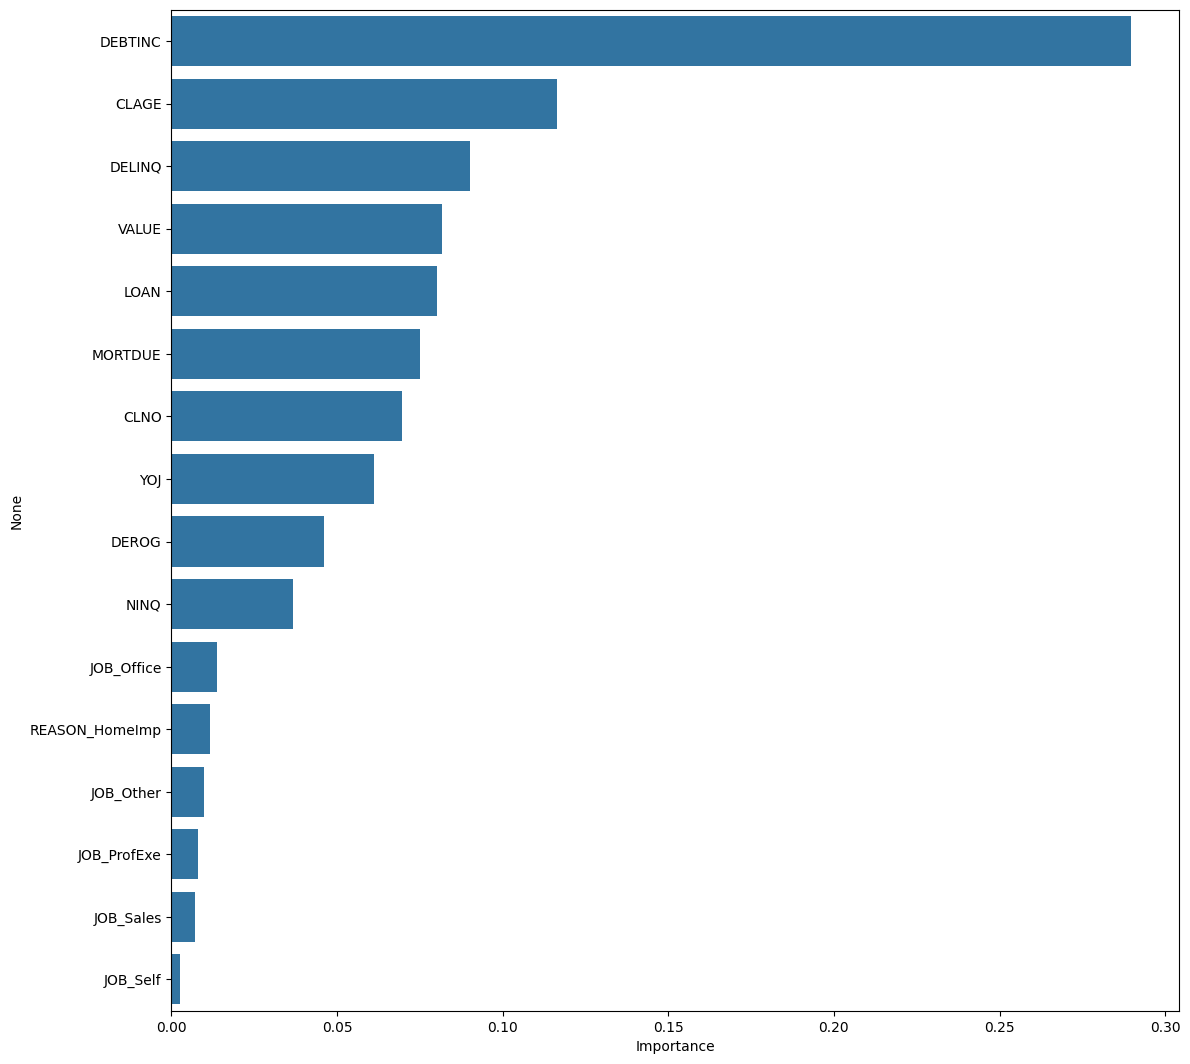

In [ ]:
importances = rf_estimator.feature_importances_

columns = x.columns

importance_df = pd.DataFrame(importances, index = columns, columns = ['Importance']).sort_values(by = 'Importance', ascending = False)

plt.figure(figsize = (13, 13))

sns.barplot(x= importance_df.Importance, y=importance_df.index);

**Observations:**


- The Random Forest further verifies the results from the decision tree that the most important features are `DEBTINC`, `CLAGE`, `DELINQ`.
- `VALUE`, `LOAN`, `MORTDUE`, & `CLNO` have roughly equal importance
- `YOJ`, to a lesser degree `DEROG` and finally `NINQ` have less importance
- Having an office job (`JOB`) and home improvement (`REASON`) are the leading values


### **Random Forest Classifier Hyperparameter Tuning**

**n_estimators**: The number of trees in the forest.

**min_samples_split**: The minimum number of samples required to split an internal node.

**min_samples_leaf**: The minimum number of samples required to be at a leaf node.

**max_features{“auto”, “sqrt”, “log2”, 'None'}**: The number of features to consider when looking for the best split.

- If “auto”, then max_features=sqrt(n_features).

- If “sqrt”, then max_features=sqrt(n_features) (same as “auto”).

- If “log2”, then max_features=log2(n_features).

- If None, then max_features=n_features.

In [ ]:
# Choose the type of classifier
rf_estimator_tuned = RandomForestClassifier(class_weight = {0: 0.17, 1: 0.83}, random_state = 1)

# Grid of parameters to choose from
params_rf = {
        "n_estimators": [100, 250, 500],
        "min_samples_leaf": np.arange(1, 4, 1),
        "max_features": [0.7, 0.9, 'auto'],
}


# Type of scoring used to compare parameter combinations - recall score for class 1
scorer = metrics.make_scorer(recall_score, pos_label = 1)

# Run the grid search
grid_obj = GridSearchCV(rf_estimator_tuned, params_rf, scoring = scorer, cv = 5)

grid_obj = grid_obj.fit(x_train, y_train)

# Set the classifier to the best combination of parameters
rf_estimator_tuned = grid_obj.best_estimator_

In [ ]:
rf_estimator_tuned.fit(x_train, y_train)

RandomForestClassifier(class_weight={0: 0.17, 1: 0.83}, max_features=0.7,
                       min_samples_leaf=np.int64(3), n_estimators=250,
                       random_state=1)

RandomForestClassifier(class_weight={0: 0.17, 1: 0.83}, max_features=0.7,
                       min_samples_leaf=np.int64(3), n_estimators=250,
                       random_state=1)

              precision    recall  f1-score   support

           0       1.00      0.97      0.98      3817
           1       0.89      0.99      0.94       951

    accuracy                           0.97      4768
   macro avg       0.94      0.98      0.96      4768
weighted avg       0.98      0.97      0.97      4768



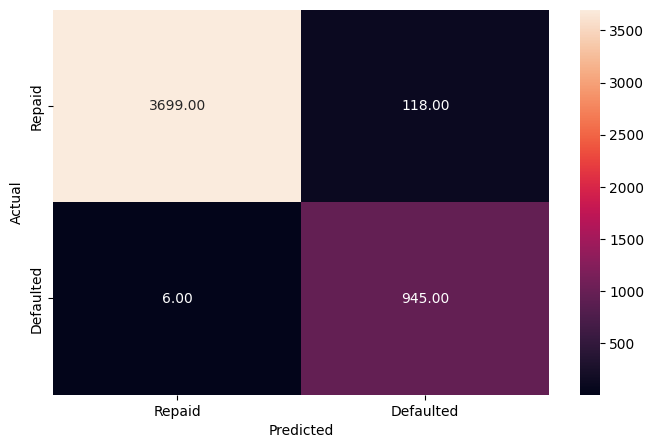

In [ ]:
# Checking performance on the training data
y_pred_train_rf_tuned = rf_estimator_tuned.predict(x_train)

metrics_score(y_train, y_pred_train_rf_tuned)

              precision    recall  f1-score   support

           0       0.92      0.94      0.93       954
           1       0.72      0.66      0.68       238

    accuracy                           0.88      1192
   macro avg       0.82      0.80      0.80      1192
weighted avg       0.88      0.88      0.88      1192



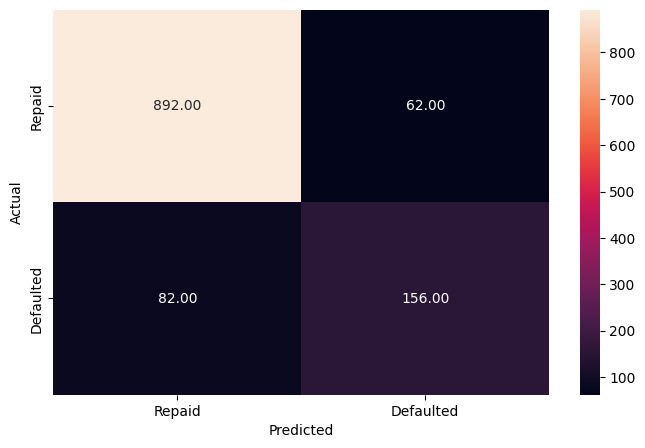

In [ ]:
# Checking performance on the test data
y_pred_test_rf_tuned = rf_estimator_tuned.predict(x_test)

metrics_score(y_test, y_pred_test_rf_tuned)

In [ ]:
rf_estimator_tuned_test = model_performance_classification(rf_estimator_tuned, x_test, y_test)
rf_estimator_tuned_test

,Precision,Recall,Accuracy
0,0.815704,0.795236,0.879195


**Observations:**

- The tuned model is also slightly overfitting the training dataset, but **it shows improved performance on the test dataset from the non tuned model.**
- **The recall for class 1 has improved from 58% to 66% with a noticeable decrease in precision 72% from 86%**.
- **This model is the best-performing one among all the models so far,** and is giving us better precision and recall scores on the test dataset.

<Axes: xlabel='Importance', ylabel='None'>

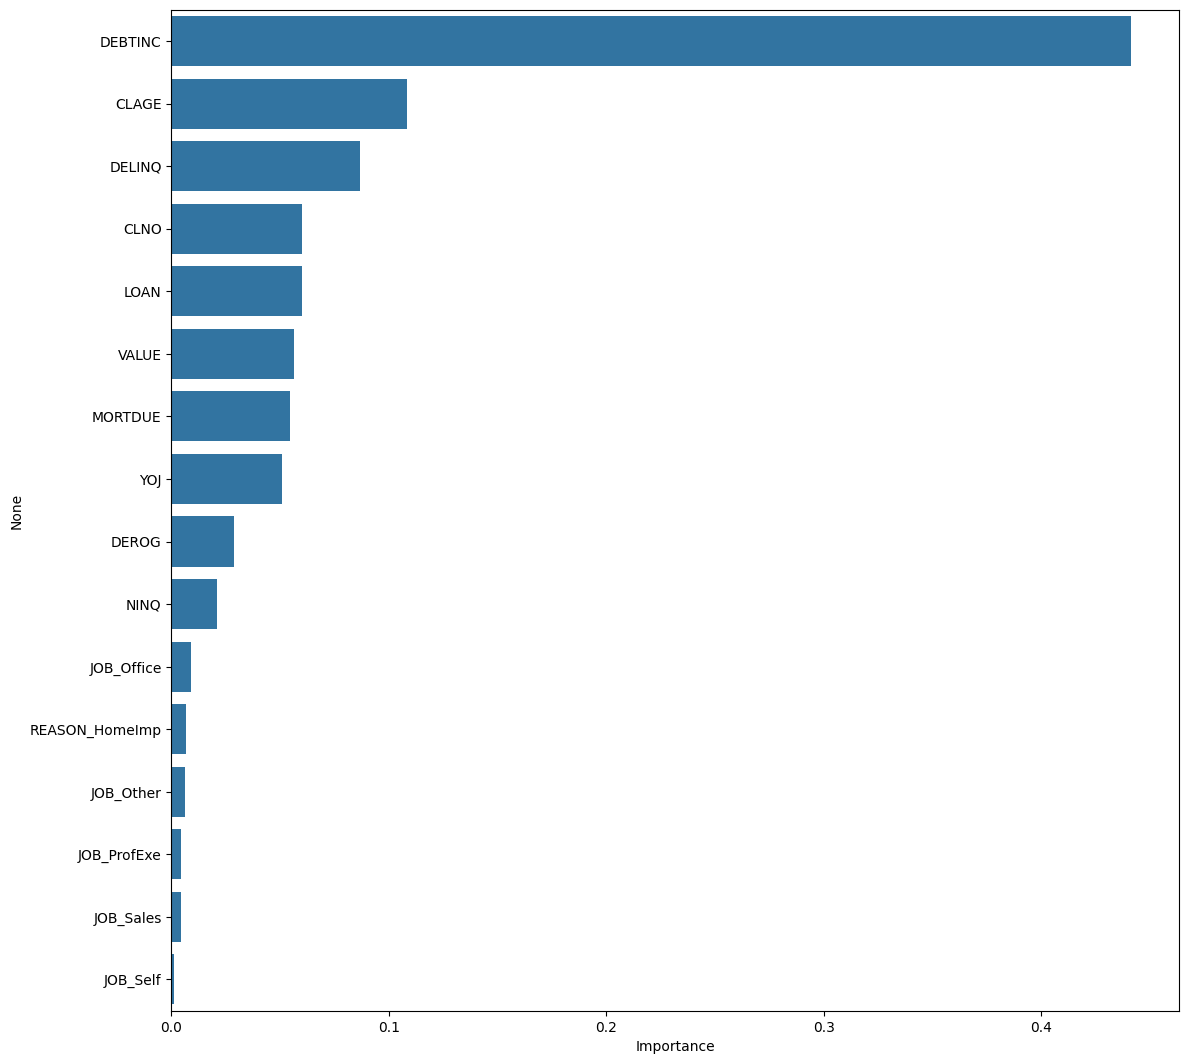

In [ ]:
# Plotting feature importance
importances = rf_estimator_tuned.feature_importances_

columns = x.columns

importance_df = pd.DataFrame(importances, index = columns, columns = ['Importance']).sort_values(by = 'Importance', ascending = False)

plt.figure(figsize = (13, 13))

sns.barplot(x= importance_df.Importance, y= importance_df.index)

In [ ]:
importances

array([0.06016817, 0.05458486, 0.05636285, 0.05100126, 0.02900826,
       0.08684321, 0.10824304, 0.02082599, 0.06026732, 0.44119943,
       0.00880145, 0.00629626, 0.00446547, 0.00434886, 0.00109379,
       0.00648978])

**Observations:**

- **The feature importance plot for the base model and tuned model are quite similar.** The tuned Random Forest further verifies the results from the decision tree that the most important features are `DEBTINC`, `CLAGE`, `DELINQ`.
- `CLNO`, `LOAN`, `VALUE`,`MORTDUE` & `CLNO` have roughly equal importance
- To a lesser degree `DEROG` and finally `NINQ` have less importance
- Having an office job (`JOB`) and home improvement (`REASON`) are the leading values

**1. Comparison of various techniques and their relative performance based on chosen Metric (Measure of success):**
- How do different techniques perform?
  - Logistic Regression performed poorly at 50% recall and 40% accuracy
  - Decision Tree (tuned) performed at 82% recall and 74% accuracy
  - Random Forest (tuned) performed at ~80% recall and 81% accuracy

- Which one is performing relatively better?
  - Random Forest (tuned) perfomed overall the best

- Is there scope to improve the performance further?
  - There may be improved performance by tweaking how I handled missing data and outliers.  I didn't try  removing data rows outright for missing values, nor removing columns that don't add any value, or changing how I treat outliers (I chose to copy a median).

**2. Refined insights:**
- What are the most meaningful insights relevant to the problem?



  - DEBTINC (Debt-to-Income ratio) at 44% is the single most critical factor for predicting default.
    - I would make DEBTINC a required field (given 20% of applications didn't provide them)
    - The bank’s approval logic should start and end with a strict thresholds for DEBTINC. No matter how good other features look, if this ratio is too high, the risk of default is statistically overwhelming.
    - Example thresholds (from the decision tree), if ratio is >35% the loan needs additional review, if >43% it's automatically predicted to default.  Note: These values would need to be confirmed.
  - The next 2 important factors to look at would be CLAGE and DELINQ (10.8% and 8.7%, respectively).
    - Past behavior is a much better predictor than current wealth. The model values how long a person has had credit lines opened and handles credit (delinquencies) significantly more how much they are borrowing (LOAN at ~6%).
  - Both VALUE and MORTDUE show relatively low importance (around 5.4%–5.6%).  
    - Banks often focus heavily on the collateral (the house), but the Random Forest has learned that the borrower’s cash flow and history are far more relevant to repayment than the house's market price.
  - You can ignore Jobs and Reasons (<1%)
    - Banks can stop worrying about why someone wants the money or what their specific job title is. These factors provide almost zero "information gain" compared to the hard financial numbers.  Could likely eliminate collecting this information.




**3. Proposal for the final solution design:**
- What model do you propose to be adopted? Why is this the best solution to adopt?
  - I would propose the Random Forest (tuned) model.  By averaging multiple trees, it reduces the "noise" and overfitting of a single Decision Tree while maintaining high sensitivity to the risky 20% of applicants.  It also maintains 81% accuracy and 80% recall.

  - I would avoid Logistic Regression since it assumes a linear relationship between features (like DEBTINC or CLAGE) and the target. Financial data often has "thresholds" (e.g., risk only spikes after a certain debt level), which linear models struggle to map.

**Production Recommendation**
- To maximize the 80% recall of the Random Forest model (if the bank agrees that is accurate enough), the bank should pivot from a "faceted" human review to a "formulaic" approach that prioritizes Debt-to-Income first, Credit Age second, and Credit Delinquencies third.
  - Ideally we could estimate how much of the $20M dollar we could have saved using this model
  - A conservative approach would be to run this automated model in parallel with the existing manual approach for some time and compare when the two approaches product different results and then dig into why.  Once we are comfortable with the reasons and the automated model has reached "no worse than" if not better performance than the existing model you could fully migrate over to it.


